In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy.table import Table, vstack,hstack
import astropy.io.fits as fits
import numpy.ma as ma
import scipy.optimize
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals')
from elliptical_plottingFunctions import med_err

In [3]:
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [4]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_v2.fits'
master_table = Table.read(master_table_fn, format='fits')

In [5]:
plot_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/results_plots/refit_spirals/'

In [6]:
manga_pca = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/mangapca_totalmass-1.0.0.fits')
manga_pca[:5]

plateifu,mass_in_ifu,mass_outer_ring,mass_outer_cmlr
,solMass,solMass,solMass
bytes11,float64,float64,float64
10001-1902,25648074768.173985,10927402145.799698,11528891420.106087
10001-1901,6680932262.753302,0.0,0.0
10001-3701,14695050533.737389,0.0,0.0
10001-3702,13158901899.473583,5018864841.8784,4140483918.912385
10001-6102,56851477199.11623,9679072144.908724,5202131002.418515


In [7]:
manga_pca_dict = {}
for i in range(len(manga_pca)):
    manga_pca_dict[manga_pca['plateifu'][i]] = i

In [8]:
ellipticals = master_table[master_table['Mvir'] > 0]
ellipticals = ellipticals[ellipticals['sphd_M_star']>0]
ellipticals[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64

In [9]:
ellipticals_dict = {}
for i in range(len(ellipticals)):
    ellipticals_dict[ellipticals['plateifu'][i]] = i

In [10]:
spirals = master_table[master_table['v_max'] > 0]
spirals = spirals[spirals['M90_disk'] > 0]
spirals = spirals[spirals['alpha'] <= 99]
spirals = spirals[spirals['v_max_err']/spirals['v_max'] <= 2]
v90 = spirals['v_max'] * spirals['R90_kpc'] / (spirals['r_turn']**spirals['alpha'] + spirals['R90_kpc']**spirals['alpha'])**(1/spirals['alpha'])
all_mass_spirals = spirals[np.logical_and(v90 > 10, v90 < 1000)]
spirals = all_mass_spirals[all_mass_spirals['M90_disk']>9]

### comparing models

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_68091/4000144555.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(ellipticals['mhq_M_star'], np.log10(ellipticals['mhq_chi2']), color='b', marker='.', label='modified hernquist', alpha=0.2)


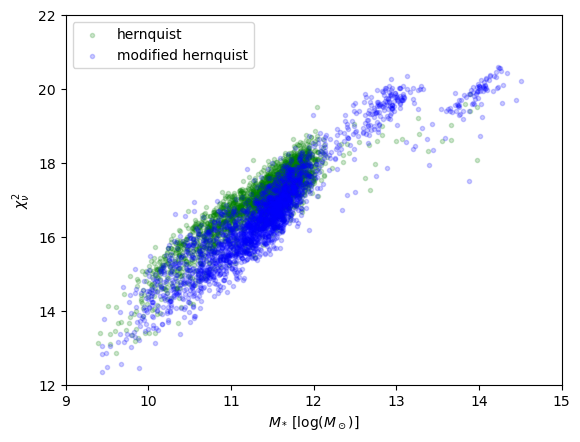

In [74]:
plt.scatter(ellipticals['hq_M_star'], np.log10(ellipticals['hq_chi2']), color='g', marker='.', label='hernquist', alpha=0.2)
plt.scatter(ellipticals['mhq_M_star'], np.log10(ellipticals['mhq_chi2']), color='b', marker='.', label='modified hernquist', alpha=0.2)
# plt.scatter(ellipticals['sph_M_star'], np.log10(ellipticals['sph_chi2']), color='k', marker='.', label='sphere', alpha=0.2)
# plt.scatter(ellipticals['sphd_M_star'], np.log10(ellipticals['sphd_chi2']), color='r', marker='.', label='sphere + disk', alpha=0.2)
plt.xlim(9,15)
plt.ylim(12, 22)
plt.xlabel(r'$M_*\, [\log(M_\odot)]$')
plt.ylabel(r'$\chi^2_\nu$')
plt.legend()
plt.savefig(plot_dir + 'Mstar_chi2nu_scatter_smass_hqmodels.png')

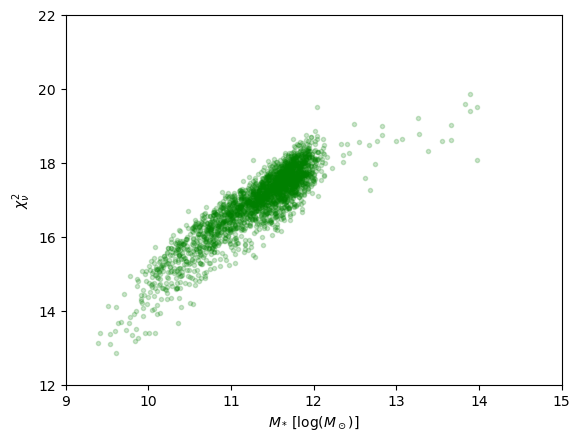

In [75]:
plt.scatter(ellipticals['hq_M_star'], np.log10(ellipticals['hq_chi2']), color='g', marker='.', label='hernquist', alpha=0.2)

plt.xlim(9,15)
plt.ylim(12, 22)
plt.xlabel(r'$M_*\, [\log(M_\odot)]$')
plt.ylabel(r'$\chi^2_\nu$')

plt.savefig(plot_dir + 'Mstar_chi2nu_scatter_smass_hq.png')

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_68091/3497979738.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(ellipticals['mhq_M_star'], np.log10(ellipticals['mhq_chi2']), color='b', marker='.', label='modified hernquist', alpha=0.2)


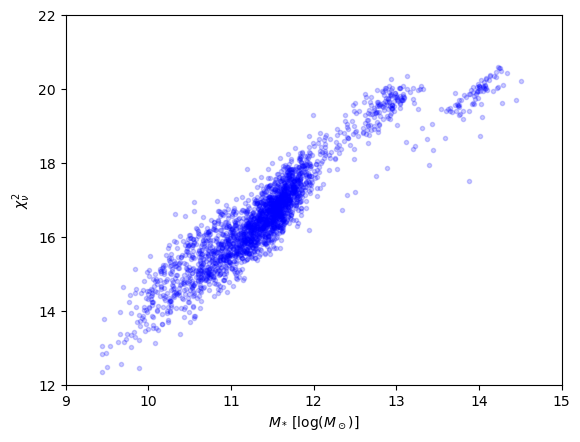

In [76]:

plt.scatter(ellipticals['mhq_M_star'], np.log10(ellipticals['mhq_chi2']), color='b', marker='.', label='modified hernquist', alpha=0.2)
plt.xlim(9,15)
plt.ylim(12, 22)
plt.xlabel(r'$M_*\, [\log(M_\odot)]$')
plt.ylabel(r'$\chi^2_\nu$')
plt.savefig(plot_dir + 'Mstar_chi2nu_scatter_smass_mhq.png')

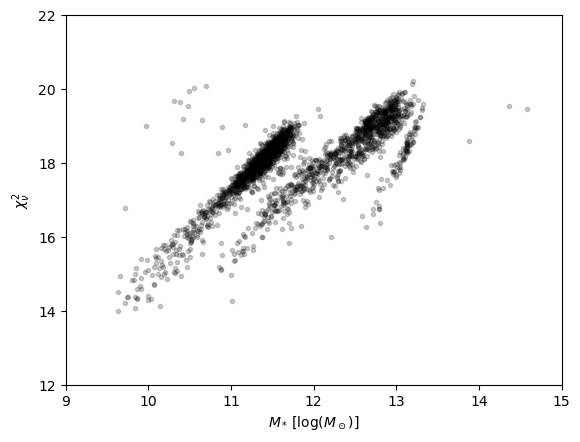

In [77]:

plt.scatter(ellipticals['sph_M_star'], np.log10(ellipticals['sph_chi2']), color='k', marker='.', label='sphere', alpha=0.2)
plt.xlim(9,15)
plt.ylim(12, 22)
plt.xlabel(r'$M_*\, [\log(M_\odot)]$')
plt.ylabel(r'$\chi^2_\nu$')
plt.savefig(plot_dir + 'Mstar_chi2nu_scatter_smass_sph.png')

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_68091/1944543324.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(ellipticals['sphd_M_star'], np.log10(ellipticals['sphd_chi2']), color='r', marker='.', label='sphere + disk', alpha=0.2)


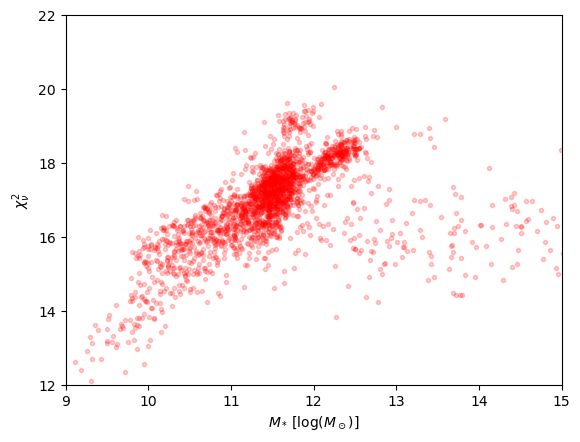

In [78]:
plt.scatter(ellipticals['sphd_M_star'], np.log10(ellipticals['sphd_chi2']), color='r', marker='.', label='sphere + disk', alpha=0.2)
plt.xlim(9,15)
plt.ylim(12, 22)
plt.xlabel(r'$M_*\, [\log(M_\odot)]$')
plt.ylabel(r'$\chi^2_\nu$')
plt.savefig(plot_dir + 'Mstar_chi2nu_scatter_smass_sphd.png')

(-15.8, -25.0)

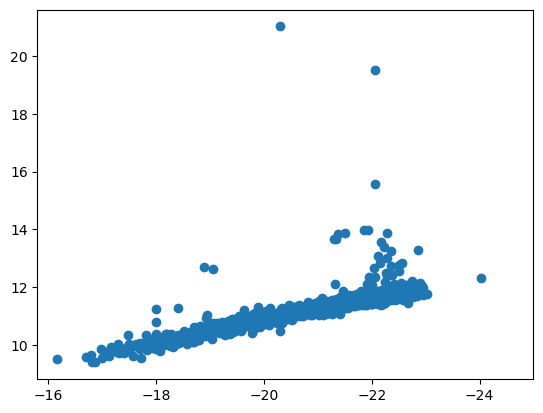

In [79]:
plt.scatter(ellipticals['rabsmag'], ellipticals['hq_M_star'])
plt.xlim(-15.8, -25)


(8.0, 13.0)

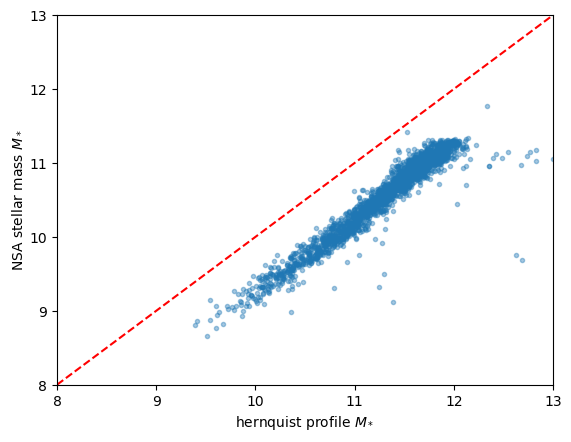

In [80]:
plt.scatter(ellipticals['hq_M_star'], ellipticals['nsa_elpetro_log_mass'], marker='.', alpha=0.4)
plt.xlabel(r'hernquist profile $M_*$')
plt.ylabel(r'NSA stellar mass $M_*$')
plt.plot([8,13],[8,13], linestyle='--', color='r')
plt.xlim(8,13)
plt.ylim(8,13)

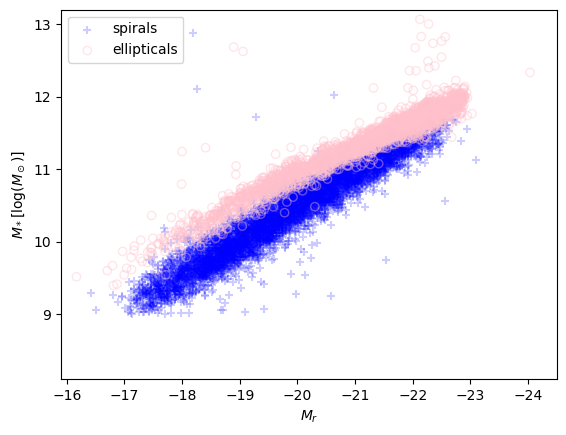

In [81]:
plt.scatter(spirals['rabsmag'], spirals['M90_disk'], color='b', alpha=0.2, marker='+', label='spirals')
plt.scatter(ellipticals['rabsmag'], ellipticals['hq_M_star'], color='pink', alpha=0.4, marker='o', 
            facecolor='None', label='ellipticals')
plt.xlim(-15.9, -24.5)
plt.ylim(8.1,13.2)
plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_* [\log(M_\odot)]$')
plt.legend()
# plt.savefig(plot_dir + 'Mr_Mstar_models_scatter_morph.png')

In [82]:
ellipticals['Mstar_Mtot'] = ellipticals['hq_M_star'] - ellipticals['Mvir']

In [83]:
spirals_mratiocut = spirals[spirals['Mstar_Mtot_R90'] <= 1.2]
mag_bins = np.linspace(np.min([np.min(ellipticals['rabsmag']), np.min(spirals['rabsmag'])]),
                       np.max([np.max(ellipticals['rabsmag']), np.max(spirals['rabsmag'])]),
                       30)
pts = (mag_bins[1:] + mag_bins[:-1]) / 2
e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = mag_bins[i+1]
    if i == 0:
        e_mratio.append(10**ellipticals['Mstar_Mtot'][ellipticals['rabsmag'] <= mag_lim])
        s_mratio.append(10**spirals_mratiocut['Mstar_Mtot_R90'][spirals_mratiocut['rabsmag'] <= mag_lim])

    else:
        lower_lim = mag_bins[i]
        e_mratio.append(10**ellipticals['Mstar_Mtot'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)])
        
        s_mratio.append(10**spirals_mratiocut['Mstar_Mtot_R90'][np.logical_and(spirals_mratiocut['rabsmag'] <= mag_lim, 
                                                                         spirals_mratiocut['rabsmag'] > lower_lim)])


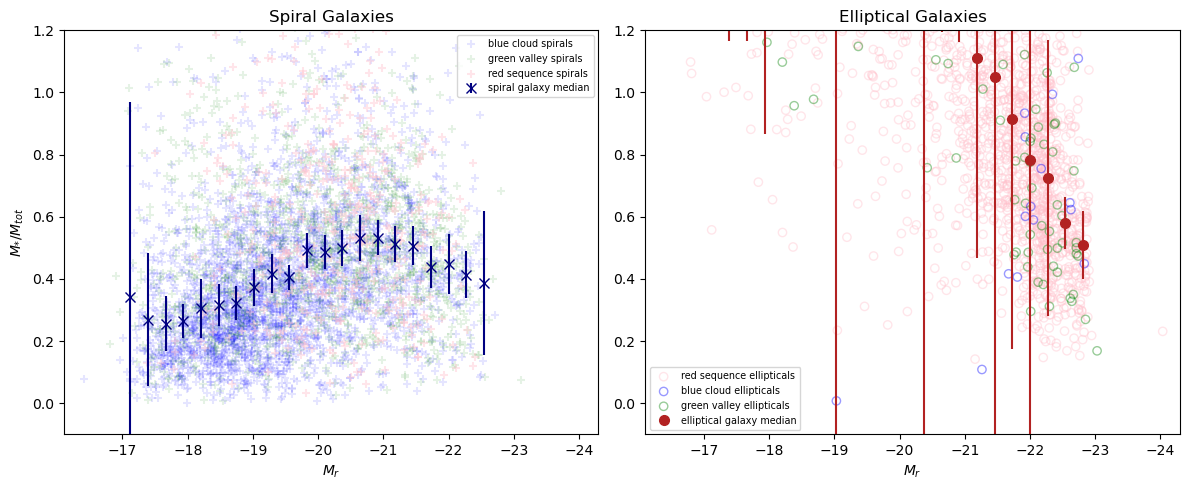

In [84]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

#labels

ax[0].set_title('Spiral Galaxies')
ax[1].set_title('Elliptical Galaxies')
ax[0].set_xlim(-16.1,-24.3)
ax[1].set_xlim(-16.1,-24.3)


ax[0].set_ylabel(r'$M_{*}/M_{tot}$')
ax[0].set_xlabel('$M_r$')
ax[1].set_xlabel('$M_r$')
ax[0].set_ylim(-0.1,1.2)
ax[1].set_ylim(-0.1,1.2)


# spirals
ax[0].scatter(spirals_mratiocut['rabsmag'][spirals_mratiocut['CMD_class'] == 1], 10**spirals_mratiocut['Mstar_Mtot_R90'][spirals_mratiocut['CMD_class'] == 1],
              marker='+', color='b', alpha=0.1, label='blue cloud spirals')
ax[0].scatter(spirals_mratiocut['rabsmag'][spirals_mratiocut['CMD_class'] == 2], 10**spirals_mratiocut['Mstar_Mtot_R90'][spirals_mratiocut['CMD_class'] == 2],
              marker='+', color='g', alpha=0.1, label='green valley spirals')
ax[0].scatter(spirals_mratiocut['rabsmag'][spirals_mratiocut['CMD_class'] == 3], 10**spirals_mratiocut['Mstar_Mtot_R90'][spirals_mratiocut['CMD_class'] == 3],
              marker='+', color='pink', alpha=0.4, label='red sequence spirals')


sp_mratio = med_err(s_mratio, False, False)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
ax[0].errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
ax[0].errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
ax[0].errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


# ellipticals

ax[1].scatter(ellipticals['rabsmag'][ellipticals['CMD_class'] == 3], 10**ellipticals['Mstar_Mtot'][ellipticals['CMD_class'] == 3],
              marker='o', color='pink', alpha=0.4, label='red sequence ellipticals', fc='none')
ax[1].scatter(ellipticals['rabsmag'][ellipticals['CMD_class'] == 1], 10**ellipticals['Mstar_Mtot'][ellipticals['CMD_class'] == 1],
              marker='o', color='b', alpha=0.4, label='blue cloud ellipticals', fc='none')
ax[1].scatter(ellipticals['rabsmag'][ellipticals['CMD_class'] == 2], 10**ellipticals['Mstar_Mtot'][ellipticals['CMD_class'] == 2],
              marker='o', color='g', alpha=0.4, label='green valley ellipticals', fc='none')


ep_mratio = med_err(e_mratio, False, False)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
ax[1].errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
ax[1].errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
ax[1].errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

ax[0].legend(fontsize='x-small')
ax[1].legend(fontsize='x-small')

fig.tight_layout()
# fig.savefig(plot_dir + 'Mr_MstarMtot_scatter_cmd_spiral_elliptical.png')

Text(0, 0.5, '$M_{\\rm tot}$')

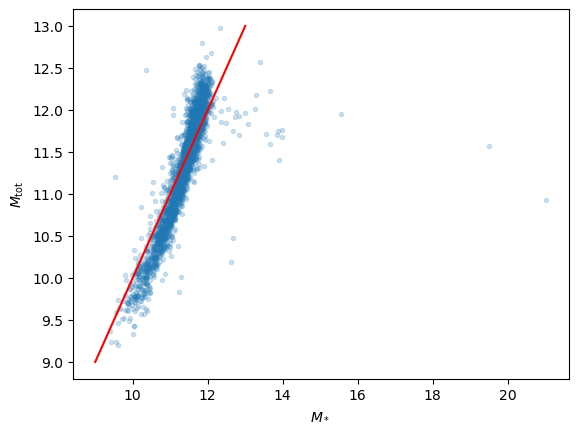

In [85]:
plt.scatter(ellipticals['hq_M_star'], ellipticals['Mvir'], alpha=0.2, marker='.')
plt.plot([9,13],[9,13], color='r')
plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{\rm tot}$')

### M/L tests

In [150]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                   np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]),
                   15)
pts = (bins[1:] + bins[:-1])/2

e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(ellipticals['sphd_M_star'][ellipticals['rabsmag'] <= mag_lim])
        s_mratio.append(spirals['M90_disk'][spirals['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(ellipticals['sphd_M_star'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)])
        
        s_mratio.append(spirals['M90_disk'][np.logical_and(spirals['rabsmag'] <= mag_lim, 
                                                                         spirals['rabsmag'] > lower_lim)])


In [167]:
print(np.max(e_mratio[8]))
print(np.median(e_mratio[8]))

13.730650511953602
10.355235512614993


In [155]:
ep_mratio

array([[11.76893015,  0.03982626,  0.03647888],
       [11.60649788,         inf,  0.63003786],
       [11.46409919,  0.02539585,  0.02399249],
       [11.28042378,  0.02858281,  0.02681725],
       [11.11688505,  0.0361247 ,  0.03334923],
       [10.91906229,         inf,  3.9771825 ],
       [10.71383057,         inf,  0.61551044],
       [10.55312221,         inf,  3.3503763 ],
       [10.35524152,         inf,  1.33819169],
       [10.08313367,         inf,  2.54526075],
       [ 9.90639706,         inf,  1.55413201],
       [ 9.76101055,         inf,  1.2589775 ],
       [        nan,         nan,         nan],
       [        nan,         nan,         nan]])

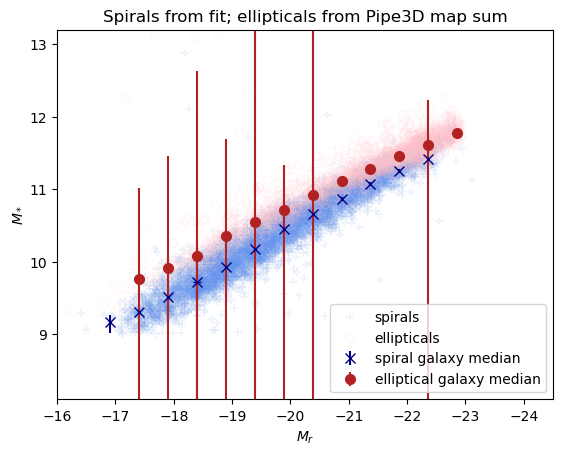

In [154]:
plt.scatter(spirals['rabsmag'], spirals['M90_disk'], marker='+', color='cornflowerblue', label='spirals', alpha=0.1)
plt.scatter(ellipticals['rabsmag'],ellipticals['sphd_M_star'], marker='o', color='pink', label='ellipticals', alpha=0.1, facecolor='None')
plt.xlim(-16,-24.5)
plt.ylim(8.1,13.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_*$')
plt.title('Spirals from fit; ellipticals from Pipe3D map sum')

sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

plt.legend()

plt.savefig(plot_dir + 'Mr_Mstar_sphd.png')

In [66]:
sp_mratio

array([[        nan,         nan,         nan],
       [11.4122981 ,  0.04313063,  0.03923155],
       [11.24831459,  0.02961064,  0.02771998],
       [11.07198502,  0.02216402,  0.0210876 ],
       [10.86479583,  0.02307587,  0.02191136],
       [10.65286141,  0.01988207,  0.01901157],
       [10.44335835,  0.01927521,  0.01845595],
       [10.17361152,  0.0287609 ,  0.02697395],
       [ 9.93018333,  0.01965626,  0.018805  ],
       [ 9.71266023,         inf,  0.53156559],
       [ 9.50757237,  0.02811383,  0.02640402],
       [ 9.30506761,  0.03503873,  0.03242165],
       [ 9.16156756,  0.14534151,  0.10870689],
       [        nan,         nan,         nan]])

In [67]:
sp_mratio=sp_mratio[1:]
sp_mratio = sp_mratio[:-1]
sp_mratio

array([[11.4122981 ,  0.04313063,  0.03923155],
       [11.24831459,  0.02961064,  0.02771998],
       [11.07198502,  0.02216402,  0.0210876 ],
       [10.86479583,  0.02307587,  0.02191136],
       [10.65286141,  0.01988207,  0.01901157],
       [10.44335835,  0.01927521,  0.01845595],
       [10.17361152,  0.0287609 ,  0.02697395],
       [ 9.93018333,  0.01965626,  0.018805  ],
       [ 9.71266023,         inf,  0.53156559],
       [ 9.50757237,  0.02811383,  0.02640402],
       [ 9.30506761,  0.03503873,  0.03242165],
       [ 9.16156756,  0.14534151,  0.10870689]])

In [68]:
def chi2_mass_lum(params, pts, medians, err):

    a,b = params

    model = a*pts + b

    chi2 = np.sum((model - medians)**2/err**2)

    return chi2

def chi2_mass_lum_break(params, pts, medians, err):

    a,b,c,d,br = params

    faint_mask = pts > br
    bright_mask = pts < br

    faint_model = a*pts[faint_mask] + b
    bright_model = c*pts[bright_mask] + d

    chi2 = np.sum((faint_model-medians[faint_mask])**2/err[faint_mask]**2) + \
            np.sum((bright_model-medians[bright_mask])**2/err[bright_mask]**2)

    return chi2


In [69]:
sp_res = scipy.optimize.minimize(chi2_mass_lum,
                                 [-0.3, -0.4],
                                  method='Powell',
                              args=(pts[1:-1],sp_mratio[:,0], sp_mratio[:,2])
                             )
sp_res

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 19.266596314099218
       x: [-4.439e-01  1.578e+00]
     nit: 3
   direc: [[ 0.000e+00  1.000e+00]
           [ 9.810e-02  1.961e+00]]
    nfev: 105

In [70]:
ep_mratio

array([[11.76893015,  0.03982626,  0.03647888],
       [11.60649788,         inf,  0.63003786],
       [11.46409919,  0.02539585,  0.02399249],
       [11.28042378,  0.02858281,  0.02681725],
       [11.11688505,  0.0361247 ,  0.03334923],
       [10.91906229,         inf,  3.9771825 ],
       [10.71383057,         inf,  0.61551044],
       [10.55312221,         inf,  3.3503763 ],
       [10.35524152,         inf,  1.33819169],
       [10.08313367,         inf,  2.54526075],
       [ 9.90639706,         inf,  1.55413201],
       [ 9.76101055,         inf,  1.2589775 ],
       [        nan,         nan,         nan],
       [        nan,         nan,         nan]])

In [71]:
ep_mratio=ep_mratio[:-2]

In [72]:
e_res = scipy.optimize.minimize(chi2_mass_lum,
                                 [-0.3, -0.4],
                                  method='Powell',
                              args=(pts[:-2],ep_mratio[:,0], ep_mratio[:,2])
                             )

e_res

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 0.5424578246529758
       x: [-3.333e-01  4.162e+00]
     nit: 3
   direc: [[ 0.000e+00  1.000e+00]
           [ 2.100e-01  4.555e+00]]
    nfev: 84

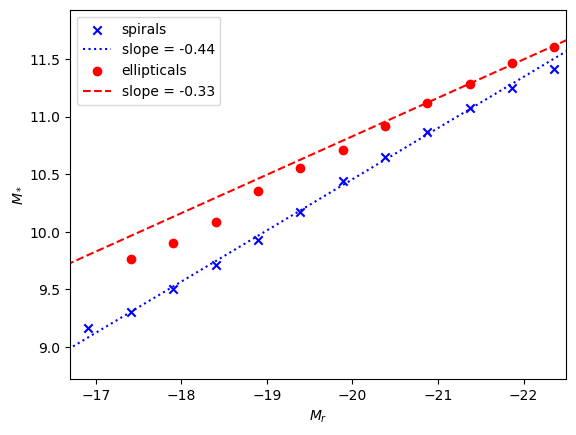

In [73]:
xs = np.linspace(pts[0], pts[-1], 50)
plt.scatter(pts[1:-1], sp_mratio[:,0], color='b', marker='x', label='spirals')
s_ys = sp_res.x[0]*xs + sp_res.x[1]
plt.plot(xs, s_ys, color='b', linestyle = ':', label='slope = {:.2f}'.format(sp_res.x[0]))

plt.scatter(pts[:-2], ep_mratio[:,0], color='r', marker='o', label='ellipticals')
plt.plot(xs, e_res.x[0]*xs + e_res.x[1], color='r', linestyle='--', label='slope = {:.2f}'.format(e_res.x[0]))

plt.xlim(-16.7, -22.5)
plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_*$')
plt.legend()
plt.savefig(plot_dir + 'Mr_Mstar_slope.png')

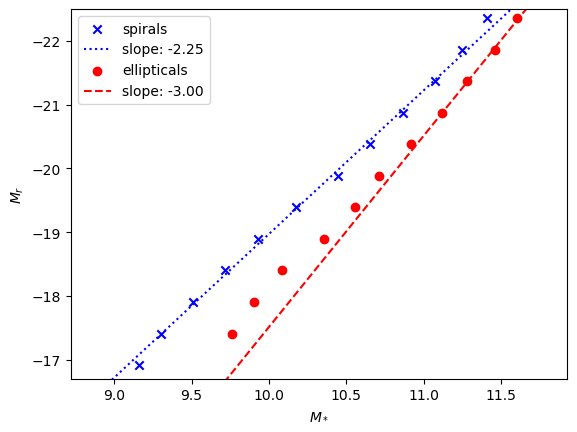

In [74]:
xs = np.linspace(pts[0], pts[-1], 50)
plt.scatter(sp_mratio[:,0],pts[1:-1], color='b', marker='x', label='spirals')
s_ys = sp_res.x[0]*xs + sp_res.x[1]
plt.plot(s_ys, xs, color='b', linestyle = ':', label='slope: {:.2f}'.format(1/sp_res.x[0]))

plt.scatter(ep_mratio[:,0],pts[0:-2], color='r', marker='o', label='ellipticals')
plt.plot(e_res.x[0]*xs + e_res.x[1], xs, color='r', linestyle='--', label='slope: {:.2f}'.format(1/e_res.x[0]))

plt.ylim(-16.7, -22.5)
plt.ylabel(r'$M_r$')
plt.xlabel(r'$M_*$')
plt.legend()
plt.savefig(plot_dir + 'Mstar_Mr_slope.png')

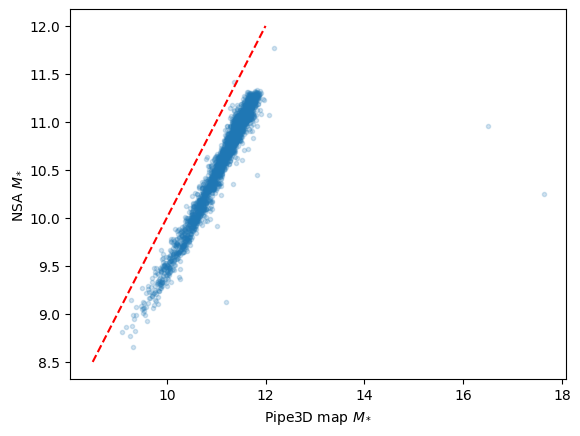

In [44]:
plt.scatter(ellipticals['sum_M_star'], ellipticals['nsa_elpetro_log_mass'], marker='.', alpha=0.2)
plt.plot([8.5,12],[8.5,12], linestyle='--', color='r')
plt.xlabel(r'Pipe3D map $M_*$')
plt.ylabel(r'NSA $M_*$')
plt.savefig(plot_dir + 'Pipe3DMstarSum_NSAMstar.png')

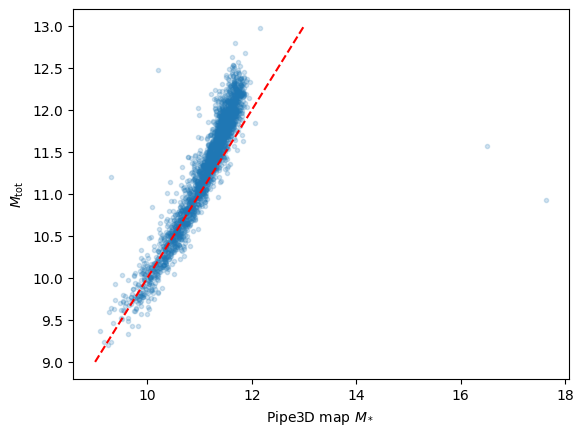

In [45]:
plt.scatter(ellipticals['sum_M_star'], ellipticals['Mvir'], marker='.', alpha=0.2)
plt.xlabel(r'Pipe3D map $M_*$')
plt.ylabel(r'$M_{\rm tot}$')
plt.plot([9,13],[9,13], color='r', linestyle='--')
plt.savefig(plot_dir + 'Pipe3DMstarSum_Mtot_scatter_ellipticals.png')

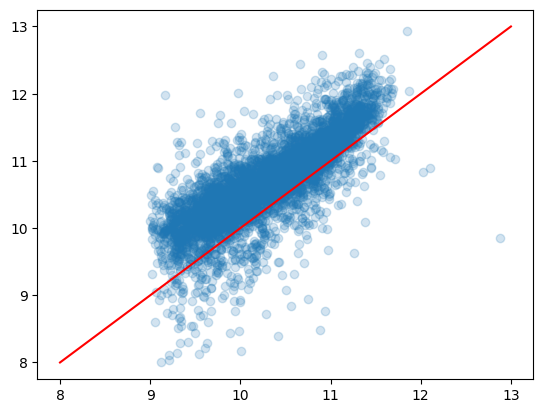

In [52]:
plt.scatter(spirals['M90_disk'], spirals['M_R90'], alpha=0.2)
plt.plot([8,13],[8,13], color='r')

In [53]:
pts

array([ 1.25,  3.75,  6.25,  8.75, 11.25, 13.75, 16.25, 18.75, 21.25,
       23.75, 26.25, 28.75, 31.25, 33.75, 36.25, 38.75, 41.25, 43.75,
       46.25, 48.75, 51.25, 53.75, 56.25, 58.75])

In [57]:
all_rmax

array([ 232, 1788, 1790, 1390,  934,  623,  441,  317,  232,  158,  117,
         99,   65,   52,   36,   24,   12,    6,    9,    5,    3,    6,
          2,    0])

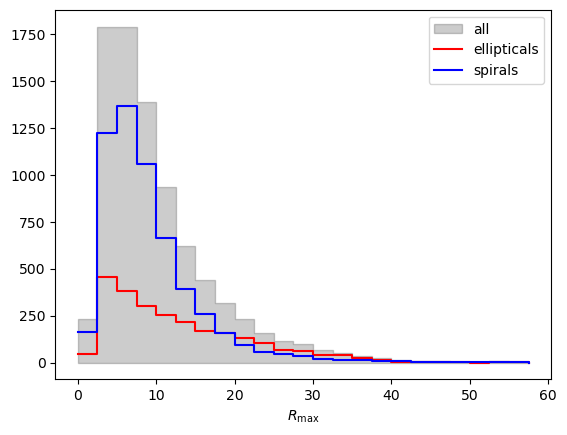

In [64]:
bins = np.linspace(0,60, 25)
pts = (bins[1:] + bins[:-1])/2

e_rmax, _ = np.histogram(ellipticals['Rmax'], bins=bins)
s_rmax, _ = np.histogram(spirals['Rmax'], bins=bins)
all_rmax, _ = np.histogram(master_table['Rmax'], bins=bins)

plt.fill_between(bins[:-1], all_rmax, 0, step='post', color='k', alpha=0.2, label='all')
plt.step(bins[:-1], e_rmax, color='r', where='post', label='ellipticals')
plt.step(bins[:-1], s_rmax, color='b', where='post', label='spirals')

plt.legend()
plt.xlabel(r'$R_{\rm max}$')
plt.savefig(plot_dir + 'Rmax_hist_morph.png')

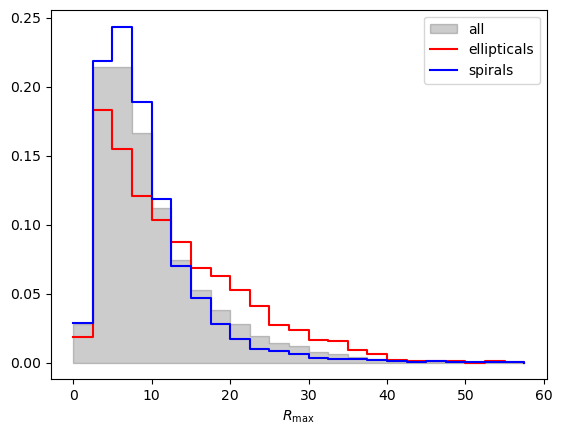

In [65]:
bins = np.linspace(0,60, 25)
pts = (bins[1:] + bins[:-1])/2

e_rmax, _ = np.histogram(ellipticals['Rmax'], bins=bins)
s_rmax, _ = np.histogram(spirals['Rmax'], bins=bins)
all_rmax, _ = np.histogram(master_table['Rmax'], bins=bins)

plt.fill_between(bins[:-1], all_rmax/len(master_table[master_table['Rmax'] >0]), 0, step='post', color='k', alpha=0.2, label='all')
plt.step(bins[:-1], e_rmax/len(ellipticals), color='r', where='post', label='ellipticals')
plt.step(bins[:-1], s_rmax/len(spirals), color='b', where='post', label='spirals')

plt.legend()
plt.xlabel(r'$R_{\rm max}$')
plt.savefig(plot_dir + 'Rmax_hist_norm_morph.png')

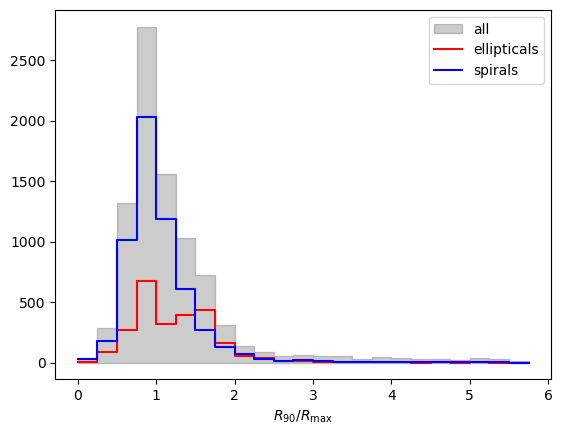

In [66]:
bins = np.linspace(0,6, 25)

e_rmax, _ = np.histogram(ellipticals['R90_kpc']/ellipticals['Rmax'], bins=bins)
s_rmax, _ = np.histogram(spirals['R90_kpc']/spirals['Rmax'], bins=bins)
all_rmax, _ = np.histogram(master_table['R90_kpc']/master_table['Rmax'], bins=bins)

plt.fill_between(bins[:-1], all_rmax, 0, step='post', color='k', alpha=0.2, label='all')
plt.step(bins[:-1], e_rmax, color='r', where='post', label='ellipticals')
plt.step(bins[:-1], s_rmax, color='b', where='post', label='spirals')

plt.legend()
plt.xlabel(r'$R_{90}/R_{\rm max}$')
plt.savefig(plot_dir + 'R90Rmax_hist_morph.png')

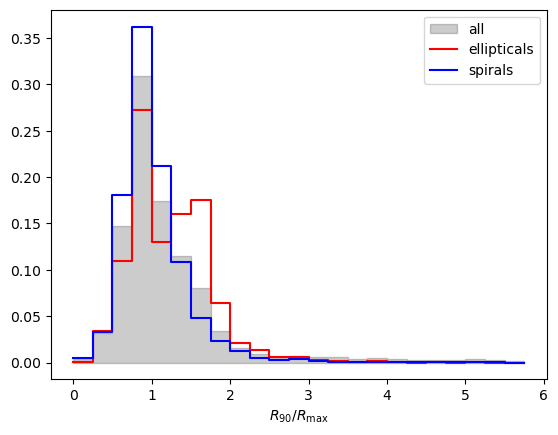

In [67]:
bins = np.linspace(0,6, 25)

e_rmax, _ = np.histogram(ellipticals['R90_kpc']/ellipticals['Rmax'], bins=bins)
s_rmax, _ = np.histogram(spirals['R90_kpc']/spirals['Rmax'], bins=bins)
all_rmax, _ = np.histogram(master_table['R90_kpc']/master_table['Rmax'], bins=bins)

plt.fill_between(bins[:-1], all_rmax/len(master_table[master_table['R90_kpc'] > 0]), 0, step='post', color='k', alpha=0.2, label='all')
plt.step(bins[:-1], e_rmax/len(ellipticals), color='r', where='post', label='ellipticals')
plt.step(bins[:-1], s_rmax/len(spirals), color='b', where='post', label='spirals')

plt.legend()
plt.xlabel(r'$R_{90}/R_{\rm max}$')
plt.savefig(plot_dir + 'R90Rmax_hist_norm_morph.png')

In [46]:
np.min(ellipticals['R90_kpc'])

1.0192686541636167

### M_r vs Mstar in R90/Rmax bins

In [96]:
all_p5R90 = master_table[master_table['R90_kpc']/master_table['Rmax'] < 0.5]
e_p5R90 = ellipticals[ellipticals['R90_kpc']/ellipticals['Rmax'] < 0.5]
s_p5R90 = spirals[spirals['R90_kpc']/spirals['Rmax'] < 0.5]

all_1R90 = master_table[np.logical_and(master_table['R90_kpc']/master_table['Rmax'] >= 0.5,master_table['R90_kpc']/master_table['Rmax'] < 1)]
e_1R90 = ellipticals[np.logical_and(ellipticals['R90_kpc']/ellipticals['Rmax'] >= 0.5,ellipticals['R90_kpc']/ellipticals['Rmax'] < 1)]
s_1R90 =  spirals[np.logical_and(spirals['R90_kpc']/spirals['Rmax'] >= 0.5,spirals['R90_kpc']/spirals['Rmax'] < 1)]

all_1p5R90 = master_table[np.logical_and(master_table['R90_kpc']/master_table['Rmax'] >= 1,master_table['R90_kpc']/master_table['Rmax'] < 1.5)]
e_1p5R90 = ellipticals[np.logical_and(ellipticals['R90_kpc']/ellipticals['Rmax'] >= 1,ellipticals['R90_kpc']/ellipticals['Rmax'] < 1.5)]
s_1p5R90 =  spirals[np.logical_and(spirals['R90_kpc']/spirals['Rmax'] >= 1,spirals['R90_kpc']/spirals['Rmax'] < 1.5)]

all_2R90 = master_table[np.logical_and(master_table['R90_kpc']/master_table['Rmax'] >= 1.5,master_table['R90_kpc']/master_table['Rmax'] < 2)]
e_2R90 = ellipticals[np.logical_and(ellipticals['R90_kpc']/ellipticals['Rmax'] >= 1.5,ellipticals['R90_kpc']/ellipticals['Rmax'] < 2)]
s_2R90 =  spirals[np.logical_and(spirals['R90_kpc']/spirals['Rmax'] >= 1.5,spirals['R90_kpc']/spirals['Rmax'] < 2)]

all_2pR90 = master_table[master_table['R90_kpc']/master_table['Rmax'] > 2]
e_2pR90 = ellipticals[ellipticals['R90_kpc']/ellipticals['Rmax'] > 2]
s_2pR90 = spirals[spirals['R90_kpc']/spirals['Rmax'] > 2]

In [104]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                   np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]),
                   15)
pts = (bins[1:] + bins[:-1])/2

all_e_mratio = []
all_s_mratio = []
for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        all_e_mratio.append(ellipticals['sum_M_star'][ellipticals['rabsmag'] <= mag_lim])
        all_s_mratio.append(spirals['M90_disk'][spirals['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        all_e_mratio.append(ellipticals['sum_M_star'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)])
        
        all_s_mratio.append(spirals['M90_disk'][np.logical_and(spirals['rabsmag'] <= mag_lim, 
                                                                         spirals['rabsmag'] > lower_lim)])

all_sp_mratio = med_err(all_s_mratio, True, True)
all_ep_mratio = med_err(all_e_mratio)

In [106]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                   np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]),
                   15)
pts = (bins[1:] + bins[:-1])/2

e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_p5R90['sum_M_star'][e_p5R90['rabsmag'] <= mag_lim])
        s_mratio.append(s_p5R90['M90_disk'][s_p5R90['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_p5R90['sum_M_star'][np.logical_and(e_p5R90['rabsmag'] <= mag_lim, 
                                                                         e_p5R90['rabsmag'] > lower_lim)])
        
        s_mratio.append(s_p5R90['M90_disk'][np.logical_and(s_p5R90['rabsmag'] <= mag_lim, 
                                                                         s_p5R90['rabsmag'] > lower_lim)])


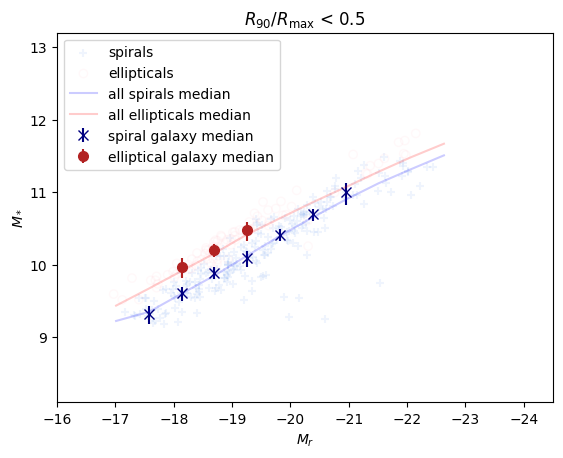

In [109]:
plt.scatter(s_p5R90['rabsmag'], s_p5R90['M90_disk'], marker='+', color='cornflowerblue', label='spirals', alpha=0.1)
plt.scatter(e_p5R90['rabsmag'],e_p5R90['sum_M_star'], marker='o', color='pink', label='ellipticals', alpha=0.1, facecolor='None')
plt.xlim(-16,-24.5)
plt.ylim(8.1,13.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_*$')
plt.title(r'$R_{90}/R_{\rm max}$ < 0.5')


sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')


plt.legend()

# plt.savefig(plot_dir + 'Mr_Mstar_mapSum.png')
plt.savefig(plot_dir + 'Mr_Mstar_mapSum_0p5.png')

In [110]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                   np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]),
                   15)
pts = (bins[1:] + bins[:-1])/2

e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_1R90['sum_M_star'][e_1R90['rabsmag'] <= mag_lim])
        s_mratio.append(s_1R90['M90_disk'][s_1R90['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_1R90['sum_M_star'][np.logical_and(e_1R90['rabsmag'] <= mag_lim, 
                                                                         e_1R90['rabsmag'] > lower_lim)])
        
        s_mratio.append(s_1R90['M90_disk'][np.logical_and(s_1R90['rabsmag'] <= mag_lim, 
                                                                         s_1R90['rabsmag'] > lower_lim)])


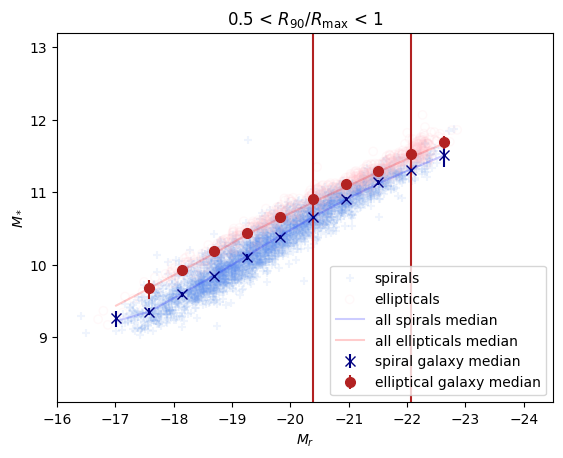

In [111]:
plt.scatter(s_1R90['rabsmag'], s_1R90['M90_disk'], marker='+', color='cornflowerblue', label='spirals', alpha=0.1)
plt.scatter(e_1R90['rabsmag'],e_1R90['sum_M_star'], marker='o', color='pink', label='ellipticals', alpha=0.1, facecolor='None')
plt.xlim(-16,-24.5)
plt.ylim(8.1,13.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_*$')
plt.title(r'0.5 < $R_{90}/R_{\rm max}$ < 1')

sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')


plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')

plt.legend()


plt.savefig(plot_dir + 'Mr_Mstar_mapSum_1.png')

In [112]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                   np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]),
                   15)
pts = (bins[1:] + bins[:-1])/2

e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_1p5R90['sum_M_star'][e_1p5R90['rabsmag'] <= mag_lim])
        s_mratio.append(s_1p5R90['M90_disk'][s_1p5R90['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_1p5R90['sum_M_star'][np.logical_and(e_1p5R90['rabsmag'] <= mag_lim, 
                                                                         e_1p5R90['rabsmag'] > lower_lim)])
        
        s_mratio.append(s_1p5R90['M90_disk'][np.logical_and(s_1p5R90['rabsmag'] <= mag_lim, 
                                                                         s_1p5R90['rabsmag'] > lower_lim)])


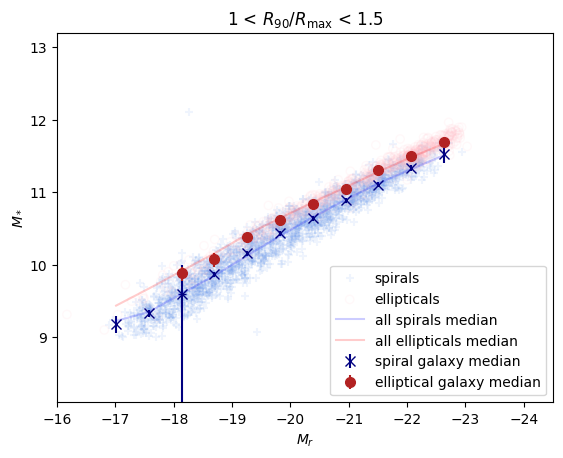

In [113]:
plt.scatter(s_1p5R90['rabsmag'], s_1p5R90['M90_disk'], marker='+', color='cornflowerblue', label='spirals', alpha=0.1)
plt.scatter(e_1p5R90['rabsmag'],e_1p5R90['sum_M_star'], marker='o', color='pink', label='ellipticals', alpha=0.1, facecolor='None')
plt.xlim(-16,-24.5)
plt.ylim(8.1,13.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_*$')
plt.title(r'1 < $R_{90}/R_{\rm max}$ < 1.5')

sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')


plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')

plt.legend()

# plt.savefig(plot_dir + 'Mr_Mstar_mapSum.png')

plt.savefig(plot_dir + 'Mr_Mstar_mapSum_1p5.png')

In [114]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                   np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]),
                   15)
pts = (bins[1:] + bins[:-1])/2

e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_2R90['sum_M_star'][e_2R90['rabsmag'] <= mag_lim])
        s_mratio.append(s_2R90['M90_disk'][s_2R90['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_2R90['sum_M_star'][np.logical_and(e_2R90['rabsmag'] <= mag_lim, 
                                                                         e_2R90['rabsmag'] > lower_lim)])
        
        s_mratio.append(s_2R90['M90_disk'][np.logical_and(s_2R90['rabsmag'] <= mag_lim, 
                                                                         s_2R90['rabsmag'] > lower_lim)])


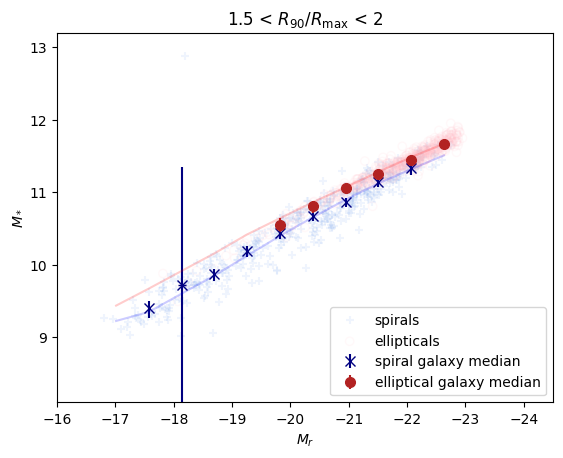

In [115]:
plt.scatter(s_2R90['rabsmag'], s_2R90['M90_disk'], marker='+', color='cornflowerblue', label='spirals', alpha=0.1)
plt.scatter(e_2R90['rabsmag'],e_2R90['sum_M_star'], marker='o', color='pink', label='ellipticals', alpha=0.1, facecolor='None')
plt.xlim(-16,-24.5)
plt.ylim(8.1,13.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_*$')
plt.title(r'1.5 < $R_{90}/R_{\rm max}$ < 2')

sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

plt.legend()


plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')

plt.savefig(plot_dir + 'Mr_Mstar_mapSum_2.png')

In [116]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                   np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]),
                   15)
pts = (bins[1:] + bins[:-1])/2

e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_2pR90['sum_M_star'][e_2pR90['rabsmag'] <= mag_lim])
        s_mratio.append(s_2pR90['M90_disk'][s_2pR90['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_2pR90['sum_M_star'][np.logical_and(e_2pR90['rabsmag'] <= mag_lim, 
                                                                         e_2pR90['rabsmag'] > lower_lim)])
        
        s_mratio.append(s_2pR90['M90_disk'][np.logical_and(s_2pR90['rabsmag'] <= mag_lim, 
                                                                         s_2pR90['rabsmag'] > lower_lim)])


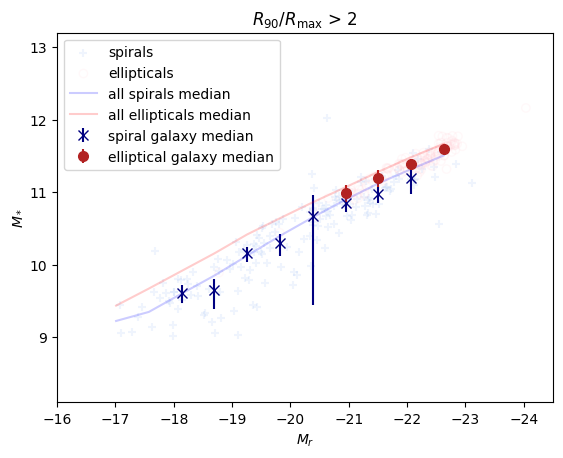

In [117]:
plt.scatter(s_2pR90['rabsmag'], s_2pR90['M90_disk'], marker='+', color='cornflowerblue', label='spirals', alpha=0.1)
plt.scatter(e_2pR90['rabsmag'],e_2pR90['sum_M_star'], marker='o', color='pink', label='ellipticals', alpha=0.1, facecolor='None')
plt.xlim(-16,-24.5)
plt.ylim(8.1,13.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_*$')
plt.title(r'$R_{90}/R_{\rm max}$ > 2')

sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')


plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')

plt.legend()

# plt.savefig(plot_dir + 'Mr_Mstar_mapSum.png')

plt.savefig(plot_dir + 'Mr_Mstar_mapSum_2p.png')

### M_* vs Mtot binned by R90/Rmax

In [174]:
# bins = np.linspace(np.min([np.min(spirals['M90_disk']), np.min(ellipticals['sum_M_star'])]),
#                    np.max([np.max(spirals['M90_disk']), np.max(ellipticals['sum_M_star'])]),
#                    15)

bins = np.linspace(np.min([np.min(spirals['M90_disk']), np.min(ellipticals['sum_M_star'])]),
                   14,
                   15)
pts = (bins[1:] + bins[:-1])/2

all_e_mratio = []
all_s_mratio = []
for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        all_e_mratio.append(ellipticals['Mvir'][ellipticals['sum_M_star'] <= mag_lim])
        all_s_mratio.append(spirals['M_R90'][spirals['M90_disk'] <= mag_lim])

    else:
        lower_lim = bins[i]
        all_e_mratio.append(ellipticals['Mvir'][np.logical_and(ellipticals['sum_M_star'] <= mag_lim, 
                                                                         ellipticals['sum_M_star'] > lower_lim)])
        
        all_s_mratio.append(spirals['M_R90'][np.logical_and(spirals['M90_disk'] <= mag_lim, 
                                                                         spirals['M90_disk'] > lower_lim)])

all_sp_mratio = med_err(all_s_mratio, True, True)
all_ep_mratio = med_err(all_e_mratio)

In [175]:
e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_p5R90['Mvir'][e_p5R90['sum_M_star'] <= mag_lim])
        s_mratio.append(s_p5R90['M_R90'][s_p5R90['M90_disk'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_p5R90['Mvir'][np.logical_and(e_p5R90['sum_M_star'] <= mag_lim, 
                                                                         e_p5R90['sum_M_star'] > lower_lim)])
        
        s_mratio.append(s_p5R90['M_R90'][np.logical_and(s_p5R90['M90_disk'] <= mag_lim, 
                                                                         s_p5R90['M90_disk'] > lower_lim)])


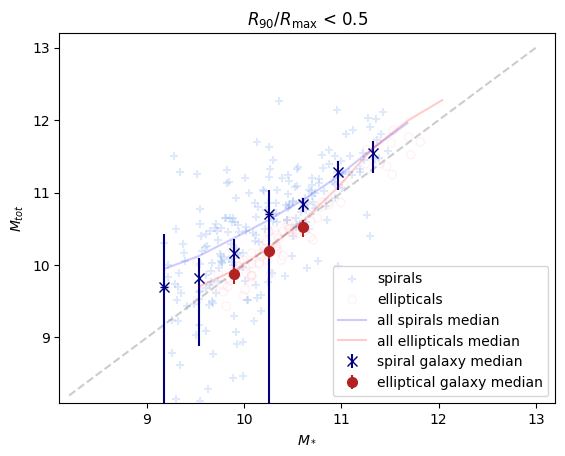

In [176]:
plt.scatter(s_p5R90['M90_disk'], s_p5R90['M_R90'], marker='+', color='cornflowerblue', label='spirals', alpha=0.2)
plt.scatter(e_p5R90['sum_M_star'],e_p5R90['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2, facecolor='None')
plt.xlim(8.1,13.2)
plt.ylim(8.1,13.2)

plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{tot}$')
plt.title(r'$R_{90}/R_{\rm max}$ < 0.5')


sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')

plt.plot([8.2,13],[8.2,13], linestyle='--', color='k', alpha=0.2)


plt.legend()

# plt.savefig(plot_dir + 'Mr_Mstar_mapSum.png')
plt.savefig(plot_dir + 'Mstar_Mtot_0p5.png')

In [177]:
e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_1R90['Mvir'][e_1R90['sum_M_star'] <= mag_lim])
        s_mratio.append(s_1R90['M_R90'][s_1R90['M90_disk'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_1R90['Mvir'][np.logical_and(e_1R90['sum_M_star'] <= mag_lim, 
                                                                         e_1R90['sum_M_star'] > lower_lim)])
        
        s_mratio.append(s_1R90['M_R90'][np.logical_and(s_1R90['M90_disk'] <= mag_lim, 
                                                                         s_1R90['M90_disk'] > lower_lim)])


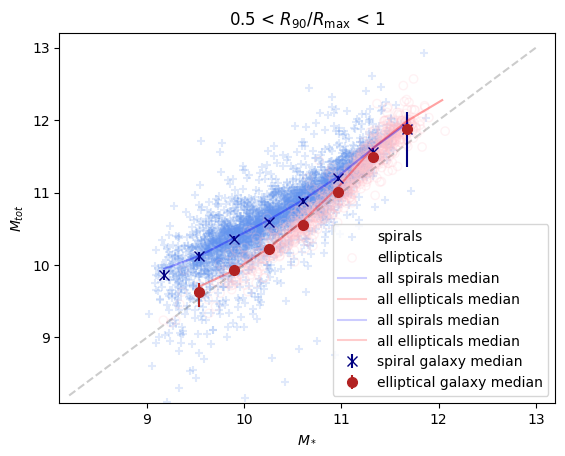

In [178]:
plt.scatter(s_1R90['M90_disk'], s_1R90['M_R90'], marker='+', color='cornflowerblue', label='spirals', alpha=0.2)
plt.scatter(e_1R90['sum_M_star'],e_1R90['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2, facecolor='None')
plt.xlim(8.1,13.2)
plt.ylim(8.1,13.2)


plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{tot}$')
plt.title(r'0.5 < $R_{90}/R_{\rm max}$ < 1')

sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')


plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')

plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')

plt.plot([8.2,13],[8.2,13], linestyle='--', color='k', alpha=0.2)

plt.legend()


plt.savefig(plot_dir + 'Mstar_Mtot_1.png')

In [179]:


e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_1p5R90['Mvir'][e_1p5R90['sum_M_star'] <= mag_lim])
        s_mratio.append(s_1p5R90['M_R90'][s_1p5R90['M90_disk'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_1p5R90['Mvir'][np.logical_and(e_1p5R90['sum_M_star'] <= mag_lim, 
                                                                         e_1p5R90['sum_M_star'] > lower_lim)])
        
        s_mratio.append(s_1p5R90['M_R90'][np.logical_and(s_1p5R90['M90_disk'] <= mag_lim, 
                                                                         s_1p5R90['M90_disk'] > lower_lim)])


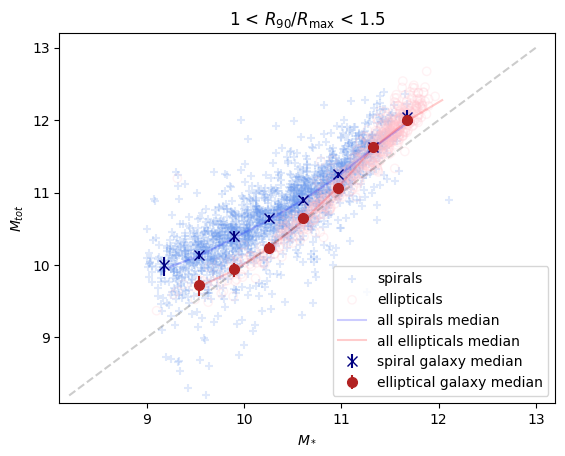

In [180]:
plt.scatter(s_1p5R90['M90_disk'], s_1p5R90['M_R90'], marker='+', color='cornflowerblue', label='spirals', alpha=0.2)
plt.scatter(e_1p5R90['sum_M_star'],e_1p5R90['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2, facecolor='None')
plt.xlim(8.1,13.2)
plt.ylim(8.1,13.2)

plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{tot}$')
plt.title(r'1 < $R_{90}/R_{\rm max}$ < 1.5')

sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')


plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')

plt.legend()

plt.plot([8.2,13],[8.2,13], linestyle='--', color='k', alpha=0.2)

# plt.savefig(plot_dir + 'Mr_Mstar_mapSum.png')

plt.savefig(plot_dir + 'Mstar_Mtot_1p5.png')

In [181]:


e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_2R90['Mvir'][e_2R90['sum_M_star'] <= mag_lim])
        s_mratio.append(s_2R90['M_R90'][s_2R90['M90_disk'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_2R90['Mvir'][np.logical_and(e_2R90['sum_M_star'] <= mag_lim, 
                                                                         e_2R90['sum_M_star'] > lower_lim)])
        
        s_mratio.append(s_2R90['M_R90'][np.logical_and(s_2R90['M90_disk'] <= mag_lim, 
                                                                         s_2R90['M90_disk'] > lower_lim)])

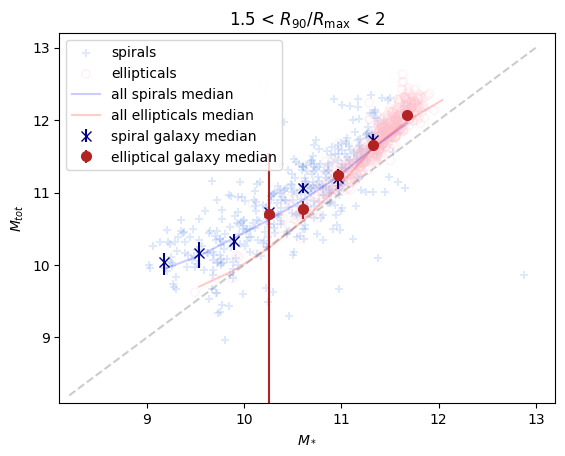

In [182]:
plt.scatter(s_2R90['M90_disk'], s_2R90['M_R90'], marker='+', color='cornflowerblue', label='spirals', alpha=0.2)
plt.scatter(e_2R90['sum_M_star'],e_2R90['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2, facecolor='None')
plt.xlim(8.1,13.2)
plt.ylim(8.1,13.2)

plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{tot}$')
plt.title(r'1.5 < $R_{90}/R_{\rm max}$ < 2')

sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')


plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')

plt.legend()

plt.plot([8.2,13],[8.2,13], linestyle='--', color='k', alpha=0.2)

# plt.savefig(plot_dir + 'Mr_Mstar_mapSum.png')

plt.savefig(plot_dir + 'Mstar_Mtot_2.png')

In [183]:
e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_2pR90['Mvir'][e_2pR90['sum_M_star'] <= mag_lim])
        s_mratio.append(s_2pR90['M_R90'][s_2pR90['M90_disk'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_2pR90['Mvir'][np.logical_and(e_2pR90['sum_M_star'] <= mag_lim, 
                                                                         e_2pR90['sum_M_star'] > lower_lim)])
        
        s_mratio.append(s_2pR90['M_R90'][np.logical_and(s_2pR90['M90_disk'] <= mag_lim, 
                                                                         s_2pR90['M90_disk'] > lower_lim)])

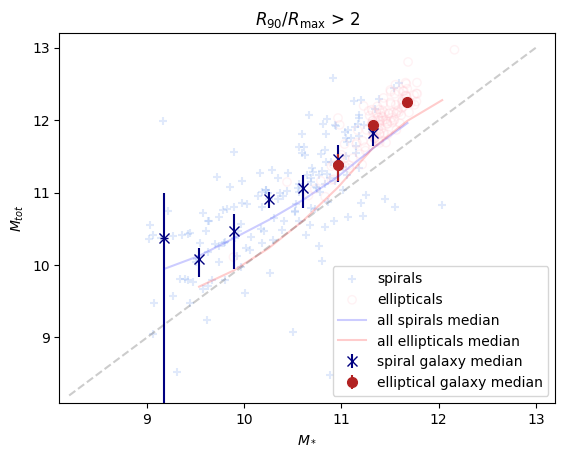

In [184]:
plt.scatter(s_2pR90['M90_disk'], s_2pR90['M_R90'], marker='+', color='cornflowerblue', label='spirals', alpha=0.2)
plt.scatter(e_2pR90['sum_M_star'],e_2pR90['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2, facecolor='None')
plt.xlim(8.1,13.2)
plt.ylim(8.1,13.2)

plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{tot}$')
plt.title(r'$R_{90}/R_{\rm max}$ > 2')

sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')


plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')


plt.plot([8.2,13],[8.2,13], linestyle='--', color='k', alpha=0.2)

plt.legend()

# plt.savefig(plot_dir + 'Mr_Mstar_mapSum.png')

plt.savefig(plot_dir + 'Mstar_Mtot_2p.png')

### Mvis vs Mtot

In [42]:
# bins = np.linspace(np.min([np.min(spirals['M90_disk']), np.min(ellipticals['sum_M_star'])]),
#                    np.max([np.max(spirals['M90_disk']), np.max(ellipticals['sum_M_star'])]),
#                    15)

bins = np.linspace(np.min([np.min(spirals['Mvis_R90']), np.min(ellipticals['sum_M_star'])]),
                   14,
                   15)
pts = (bins[1:] + bins[:-1])/2

all_e_mratio = []
all_s_mratio = []
for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        all_e_mratio.append(ellipticals['Mvir'][ellipticals
                            ['sum_M_star'] <= mag_lim])
        all_s_mratio.append(spirals['M_R90'][spirals['Mvis_R90'] <= mag_lim])

    else:
        lower_lim = bins[i]
        all_e_mratio.append(ellipticals['Mvir'][np.logical_and(ellipticals['sum_M_star'] <= mag_lim, 
                                                                         ellipticals['sum_M_star'] > lower_lim)])
        
        all_s_mratio.append(spirals['M_R90'][np.logical_and(spirals['Mvis_R90'] <= mag_lim, 
                                                                         spirals['Mvis_R90'] > lower_lim)])

all_sp_mratio = med_err(all_s_mratio, True, True)
all_ep_mratio = med_err(all_e_mratio)

In [43]:
e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_p5R90['Mvir'][e_p5R90['sum_M_star'] <= mag_lim])
        s_mratio.append(s_p5R90['M_R90'][s_p5R90['Mvis_R90'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_p5R90['Mvir'][np.logical_and(e_p5R90['sum_M_star'] <= mag_lim, 
                                                                         e_p5R90['sum_M_star'] > lower_lim)])
        
        s_mratio.append(s_p5R90['M_R90'][np.logical_and(s_p5R90['Mvis_R90'] <= mag_lim, 
                                                                         s_p5R90['Mvis_R90'] > lower_lim)])


NameError: name 'e_p5R90' is not defined

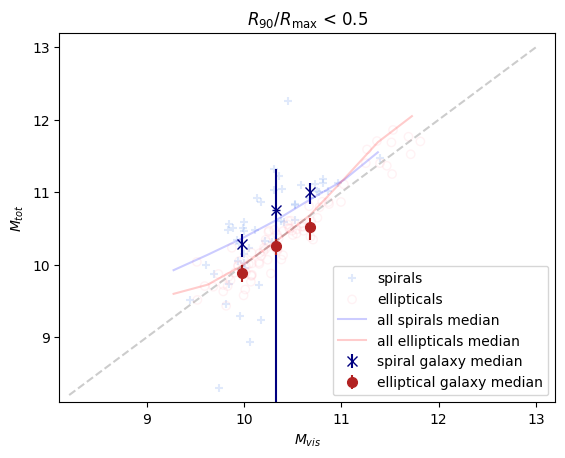

In [187]:
plt.scatter(s_p5R90['Mvis_R90'], s_p5R90['M_R90'], marker='+', color='cornflowerblue', label='spirals', alpha=0.2)
plt.scatter(e_p5R90['sum_M_star'],e_p5R90['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2, facecolor='None')
plt.xlim(8.1,13.2)
plt.ylim(8.1,13.2)

plt.xlabel(r'$M_{vis}$')
plt.ylabel(r'$M_{tot}$')
plt.title(r'$R_{90}/R_{\rm max}$ < 0.5')


sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')

plt.plot([8.2,13],[8.2,13], linestyle='--', color='k', alpha=0.2)


plt.legend()

# plt.savefig(plot_dir + 'Mr_Mstar_mapSum.png')
plt.savefig(plot_dir + 'Mvis_Mtot_0p5.png')

In [188]:
e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_1R90['Mvir'][e_1R90['sum_M_star'] <= mag_lim])
        s_mratio.append(s_1R90['M_R90'][s_1R90['Mvis_R90'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_1R90['Mvir'][np.logical_and(e_1R90['sum_M_star'] <= mag_lim, 
                                                                         e_1R90['sum_M_star'] > lower_lim)])
        
        s_mratio.append(s_1R90['M_R90'][np.logical_and(s_1R90['Mvis_R90'] <= mag_lim, 
                                                                         s_1R90['Mvis_R90'] > lower_lim)])


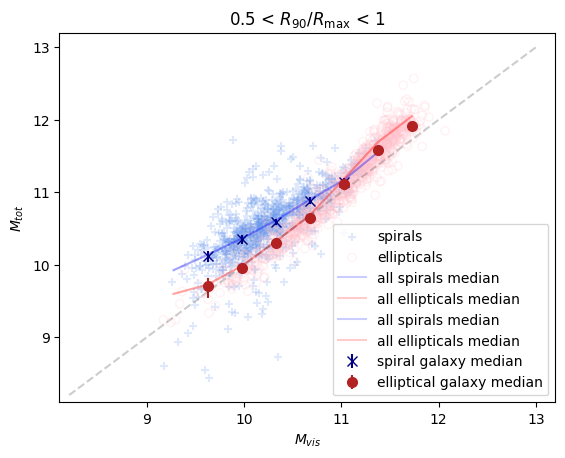

In [189]:
plt.scatter(s_1R90['Mvis_R90'], s_1R90['M_R90'], marker='+', color='cornflowerblue', label='spirals', alpha=0.2)
plt.scatter(e_1R90['sum_M_star'],e_1R90['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2, facecolor='None')
plt.xlim(8.1,13.2)
plt.ylim(8.1,13.2)


plt.xlabel(r'$M_{vis}$')
plt.ylabel(r'$M_{tot}$')
plt.title(r'0.5 < $R_{90}/R_{\rm max}$ < 1')

sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')


plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')

plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')

plt.plot([8.2,13],[8.2,13], linestyle='--', color='k', alpha=0.2)

plt.legend()


plt.savefig(plot_dir + 'Mvis_Mtot_1.png')

In [190]:


e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_1p5R90['Mvir'][e_1p5R90['sum_M_star'] <= mag_lim])
        s_mratio.append(s_1p5R90['M_R90'][s_1p5R90['Mvis_R90'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_1p5R90['Mvir'][np.logical_and(e_1p5R90['sum_M_star'] <= mag_lim, 
                                                                         e_1p5R90['sum_M_star'] > lower_lim)])
        
        s_mratio.append(s_1p5R90['M_R90'][np.logical_and(s_1p5R90['Mvis_R90'] <= mag_lim, 
                                                                         s_1p5R90['Mvis_R90'] > lower_lim)])


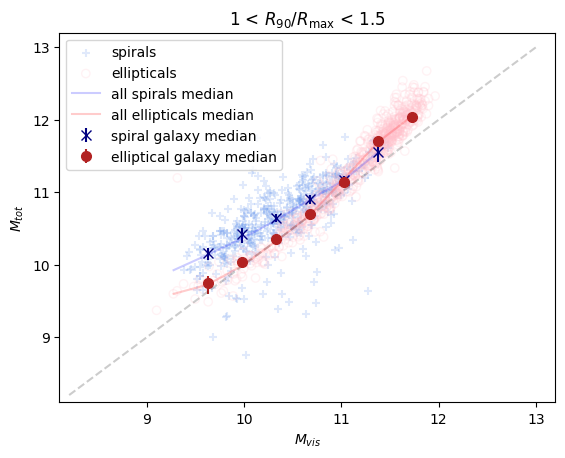

In [191]:
plt.scatter(s_1p5R90['Mvis_R90'], s_1p5R90['M_R90'], marker='+', color='cornflowerblue', label='spirals', alpha=0.2)
plt.scatter(e_1p5R90['sum_M_star'],e_1p5R90['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2, facecolor='None')
plt.xlim(8.1,13.2)
plt.ylim(8.1,13.2)

plt.xlabel(r'$M_{vis}$')
plt.ylabel(r'$M_{tot}$')
plt.title(r'1 < $R_{90}/R_{\rm max}$ < 1.5')

sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')


plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')

plt.legend()

plt.plot([8.2,13],[8.2,13], linestyle='--', color='k', alpha=0.2)

# plt.savefig(plot_dir + 'Mr_Mstar_mapSum.png')

plt.savefig(plot_dir + 'Mvis_Mtot_1p5.png')

In [192]:


e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_2R90['Mvir'][e_2R90['sum_M_star'] <= mag_lim])
        s_mratio.append(s_2R90['M_R90'][s_2R90['Mvis_R90'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_2R90['Mvir'][np.logical_and(e_2R90['sum_M_star'] <= mag_lim, 
                                                                         e_2R90['sum_M_star'] > lower_lim)])
        
        s_mratio.append(s_2R90['M_R90'][np.logical_and(s_2R90['Mvis_R90'] <= mag_lim, 
                                                                         s_2R90['Mvis_R90'] > lower_lim)])

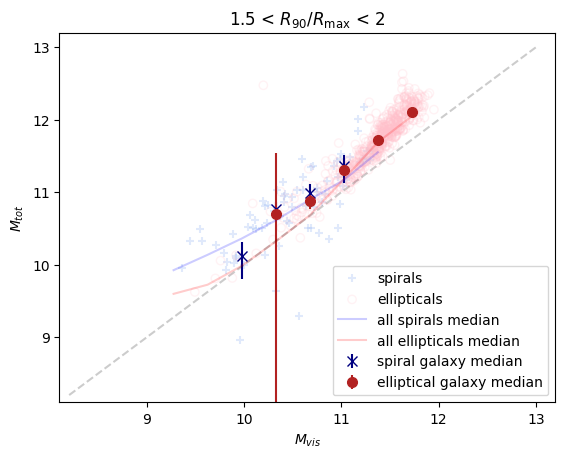

In [193]:
plt.scatter(s_2R90['Mvis_R90'], s_2R90['M_R90'], marker='+', color='cornflowerblue', label='spirals', alpha=0.2)
plt.scatter(e_2R90['sum_M_star'],e_2R90['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2, facecolor='None')
plt.xlim(8.1,13.2)
plt.ylim(8.1,13.2)

plt.xlabel(r'$M_{vis}$')
plt.ylabel(r'$M_{tot}$')
plt.title(r'1.5 < $R_{90}/R_{\rm max}$ < 2')

sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')


plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')

plt.legend()

plt.plot([8.2,13],[8.2,13], linestyle='--', color='k', alpha=0.2)

# plt.savefig(plot_dir + 'Mr_Mstar_mapSum.png')

plt.savefig(plot_dir + 'Mvis_Mtot_2.png')

In [194]:
e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(e_2pR90['Mvir'][e_2pR90['sum_M_star'] <= mag_lim])
        s_mratio.append(s_2pR90['M_R90'][s_2pR90['Mvis_R90'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(e_2pR90['Mvir'][np.logical_and(e_2pR90['sum_M_star'] <= mag_lim, 
                                                                         e_2pR90['sum_M_star'] > lower_lim)])
        
        s_mratio.append(s_2pR90['M_R90'][np.logical_and(s_2pR90['Mvis_R90'] <= mag_lim, 
                                                                         s_2pR90['Mvis_R90'] > lower_lim)])

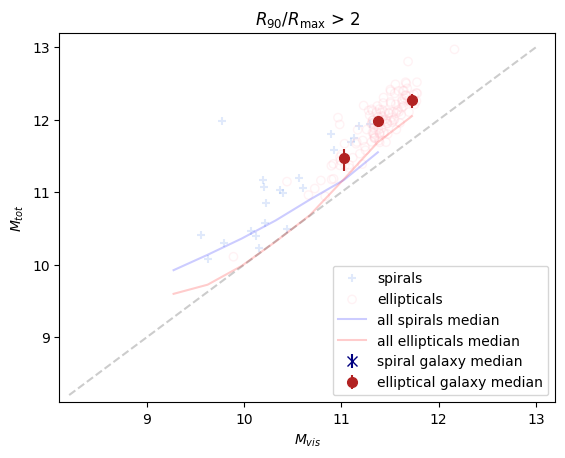

In [195]:
plt.scatter(s_2pR90['Mvis_R90'], s_2pR90['M_R90'], marker='+', color='cornflowerblue', label='spirals', alpha=0.2)
plt.scatter(e_2pR90['sum_M_star'],e_2pR90['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2, facecolor='None')
plt.xlim(8.1,13.2)
plt.ylim(8.1,13.2)

plt.xlabel(r'$M_{vis}$')
plt.ylabel(r'$M_{tot}$')
plt.title(r'$R_{90}/R_{\rm max}$ > 2')

sp_mratio = med_err(s_mratio, True, True)

inf_bars = np.where(sp_mratio == np.inf)[0]
sp_mratio[inf_bars][:,0]
plt.errorbar(pts, sp_mratio[:,0], color='navy', yerr=[sp_mratio[:,1] ,sp_mratio[:,2]], 
             marker='x', label='spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=sp_mratio[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mratio[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

ep_mratio = med_err(e_mratio)

inf_bars = np.where(ep_mratio == np.inf)[0]
ep_mratio[inf_bars][:,0]
plt.errorbar(pts, ep_mratio[:,0], color='firebrick', yerr=[ep_mratio[:,1] ,ep_mratio[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=ep_mratio[inf_bars][:,0], uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mratio[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mratio[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')


plt.plot(pts, all_sp_mratio[:,0], color='b', alpha=0.2, label='all spirals median')
plt.plot(pts, all_ep_mratio[:,0], color='r', alpha=0.2, label='all ellipticals median')


plt.plot([8.2,13],[8.2,13], linestyle='--', color='k', alpha=0.2)

plt.legend()

# plt.savefig(plot_dir + 'Mr_Mstar_mapSum.png')

plt.savefig(plot_dir + 'Mvis_Mtot_2p.png')

### galaxies with R90/Rmax < 1

In [7]:
ellipticals_small = ellipticals[ellipticals['R90_kpc']/ellipticals['Rmax'] < 1]
spirals_small = spirals[spirals['R90_kpc']/spirals['Rmax'] <1]

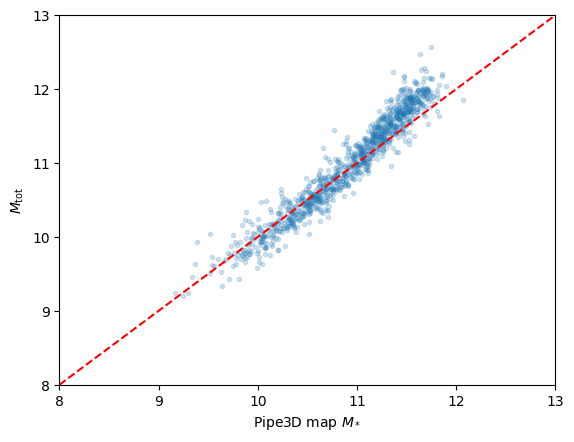

In [15]:
plt.scatter(ellipticals_small['sum_M_star'], ellipticals_small['Mvir'], marker='.', alpha=0.2)
plt.xlabel(r'Pipe3D map $M_*$')
plt.ylabel(r'$M_{\rm tot}$')
plt.xlim(8,13)
plt.ylim(8,13)
plt.plot([8,13],[8,13], color='r', linestyle='--')
plt.savefig(plot_dir + 'MstarSum_Mtot_ellipticals_small_scatter.png')

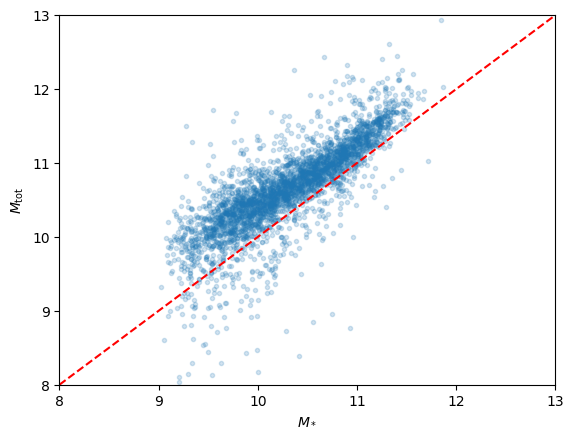

In [16]:
plt.scatter(spirals_small['M90_disk'], spirals_small['M_R90'], marker='.', alpha=0.2)
plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{\rm tot}$')
plt.xlim(8,13)
plt.ylim(8,13)
plt.plot([8,13],[8,13], color='r', linestyle='--')

plt.savefig(plot_dir + 'Mstar_Mtot_spirals_small_scatter.png')

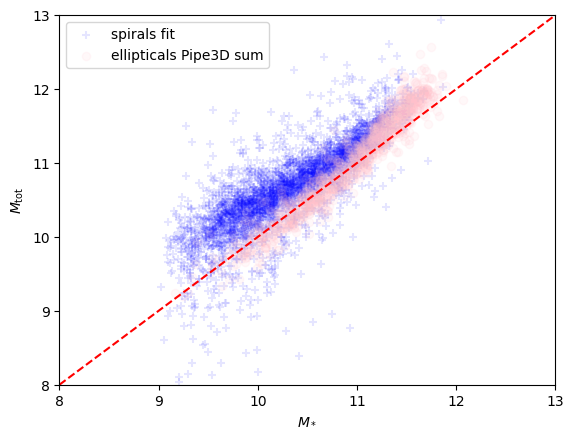

In [17]:
plt.scatter(spirals_small['M90_disk'], spirals_small['M_R90'], marker='+', color='b', alpha=0.1, label='spirals fit')
plt.scatter(ellipticals_small['sum_M_star'], ellipticals_small['Mvir'], marker='o', alpha=0.1, color='pink',label='ellipticals Pipe3D sum')
plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{\rm tot}$')
plt.xlim(8,13)
plt.ylim(8,13)
plt.plot([8,13],[8,13], color='r', linestyle='--')
plt.legend()
plt.savefig(plot_dir + 'Mstar_Mtot_ellipticals_spirals_small_scatter.png')

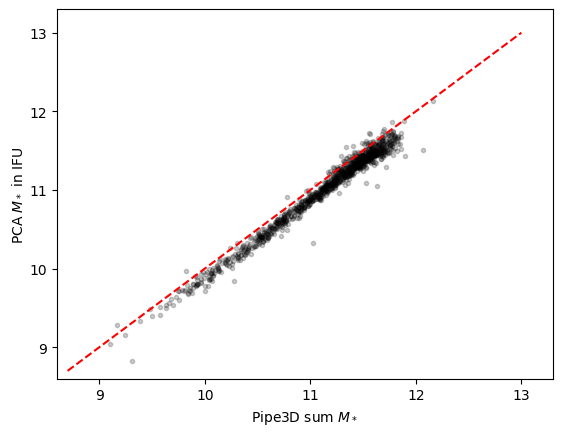

In [44]:
for i in range(len(ellipticals)):
    gal_id = ellipticals['plateifu'][i]
    try:
        pca_idx = manga_pca_dict[gal_id]
        plt.scatter(ellipticals['sum_M_star'][i], np.log10(manga_pca['mass_in_ifu'][pca_idx]), marker='.', color='k', alpha=0.2)
    except:
        continue

plt.plot([8.7,13],[8.7,13], linestyle='--', color='r')
plt.xlim(8.6, 13.3)
plt.ylim(8.6,13.3)
plt.xlabel(r'Pipe3D sum $M_*$')
plt.ylabel(r'PCA $M_*$ in IFU')
plt.savefig(plot_dir + 'Pipe3DMstar_PCAMstar_IFU_ellipticals_scatter.png')

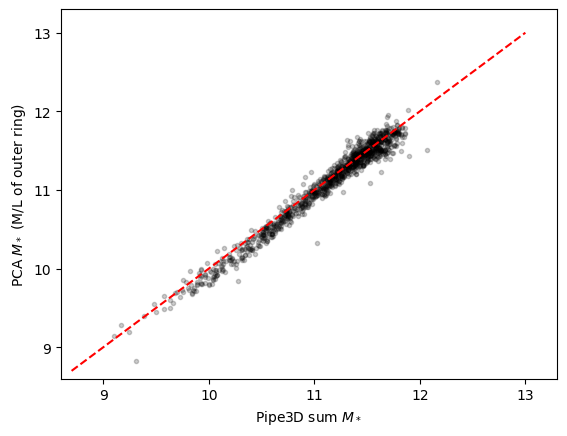

In [45]:
for i in range(len(ellipticals)):
    gal_id = ellipticals['plateifu'][i]
    try:
        pca_idx = manga_pca_dict[gal_id]
        plt.scatter(ellipticals['sum_M_star'][i], np.log10(manga_pca['mass_in_ifu'][pca_idx] + manga_pca['mass_outer_ring'][pca_idx]), marker='.', color='k', alpha=0.2)
    except:
        continue

plt.plot([8.7,13],[8.7,13], linestyle='--', color='r')
plt.xlim(8.6, 13.3)
plt.ylim(8.6,13.3)
plt.xlabel(r'Pipe3D sum $M_*$')
plt.ylabel(r'PCA $M_*$ (M/L of outer ring)')
plt.savefig(plot_dir + 'Pipe3DMstar_PCAMstar_flatML_ellipticals_scatter.png')

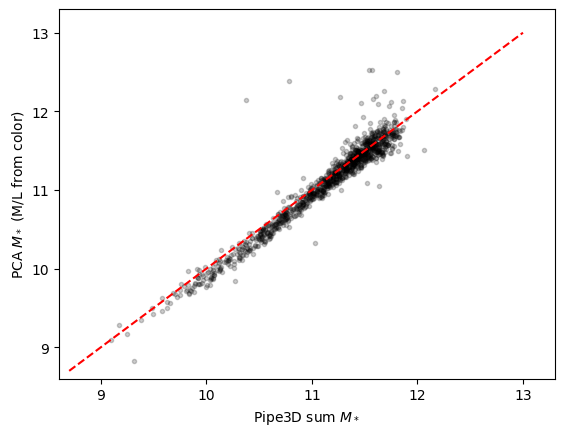

In [46]:
for i in range(len(ellipticals)):
    gal_id = ellipticals['plateifu'][i]
    try:
        pca_idx = manga_pca_dict[gal_id]
        plt.scatter(ellipticals['sum_M_star'][i], np.log10(manga_pca['mass_in_ifu'][pca_idx] + manga_pca['mass_outer_cmlr'][pca_idx]), marker='.', color='k', alpha=0.2)
    except:
        continue

plt.plot([8.7,13],[8.7,13], linestyle='--', color='r')
plt.xlim(8.6, 13.3)
plt.ylim(8.6,13.3)
plt.xlabel(r'Pipe3D sum $M_*$')
plt.ylabel(r'PCA $M_*$ (M/L from color)')
plt.savefig(plot_dir + 'Pipe3DMstar_PCAMstar_colorML_ellipticals_scatter.png')

### M* vs Mr for ellipticals and red spirals

(array([5.900e+01, 4.430e+02, 1.264e+03, 6.820e+02, 4.000e+00, 3.000e+00,
        1.000e+00, 2.000e+00, 1.000e+00, 1.000e+00]),
 array([ 9.11379695,  9.91875433, 10.7237117 , 11.52866908, 12.33362646,
        13.13858384, 13.94354122, 14.7484986 , 15.55345598, 16.35841336,
        17.16337074]),
 <BarContainer object of 10 artists>)

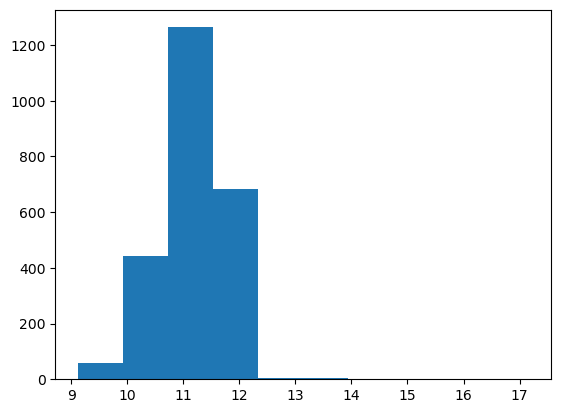

In [168]:
plt.hist(ellipticals['sphd_M_star'])

In [11]:
xp = [-23,-16]
fp = [13, 10.5]


In [12]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)
pts = (bins[:-1] + bins [1:]) / 2

red_spirals = spirals[spirals['CMD_class'] ==3]

e_mstar = []
s_mstar = []

rm_outliers = ellipticals[ellipticals['sphd_M_star'] < np.interp(ellipticals['rabsmag'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(rm_outliers['sphd_M_star'][rm_outliers['rabsmag'] <= mag_lim])
        s_mstar.append(red_spirals['M90_disk'][red_spirals['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mstar.append(rm_outliers['sphd_M_star'][np.logical_and(rm_outliers['rabsmag'] <= mag_lim, 
                                                                         rm_outliers['rabsmag'] > lower_lim)])
        
        s_mstar.append(red_spirals['M90_disk'][np.logical_and(red_spirals['rabsmag'] <= mag_lim, 
                                                                         red_spirals['rabsmag'] > lower_lim)])


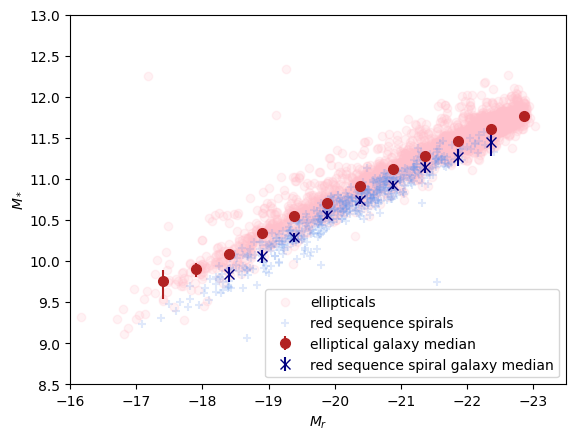

In [13]:
plt.scatter(ellipticals['rabsmag'], ellipticals['sphd_M_star'], marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(spirals['rabsmag'][spirals['CMD_class'] == 3], 
            spirals['M90_disk'][spirals['CMD_class']==3], marker='+', color='cornflowerblue', label='red sequence spirals', alpha=0.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_*$')
plt.xlim(-16, -23.5)
plt.ylim(8.5,13)
plt.legend()


sp_mstar = med_err(s_mstar)
ep_mstar = med_err(e_mstar)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9,
             # yerr=2,
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='red sequence spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], 
             yerr=sp_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


# plt.plot([-23,-16],[13, 10.5])

plt.legend()
plt.savefig(plot_dir + 'Mr_Mstar_ellipticals_redspirals_scatter.png')

In [16]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)
pts = (bins[:-1] + bins [1:]) / 2

green_spirals = spirals[spirals['CMD_class'] ==2]

e_mstar = []
s_mstar = []

rm_outliers = ellipticals[ellipticals['sphd_M_star'] < np.interp(ellipticals['rabsmag'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(rm_outliers['sphd_M_star'][rm_outliers['rabsmag'] <= mag_lim])
        s_mstar.append(green_spirals['M90_disk'][green_spirals['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mstar.append(rm_outliers['sphd_M_star'][np.logical_and(rm_outliers['rabsmag'] <= mag_lim, 
                                                                         rm_outliers['rabsmag'] > lower_lim)])
        
        s_mstar.append(green_spirals['M90_disk'][np.logical_and(green_spirals['rabsmag'] <= mag_lim, 
                                                                         green_spirals['rabsmag'] > lower_lim)])

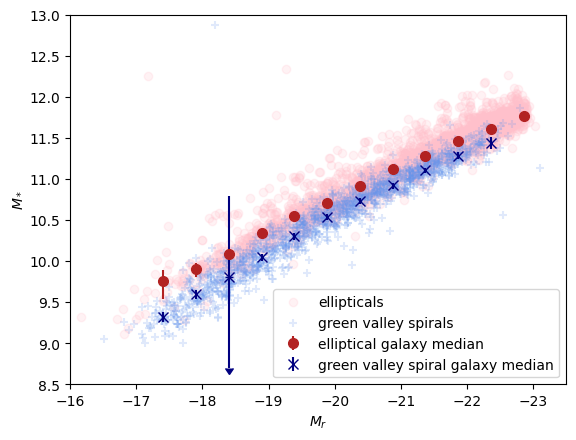

In [17]:
plt.scatter(ellipticals['rabsmag'], ellipticals['sphd_M_star'], marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(spirals['rabsmag'][spirals['CMD_class'] == 2], 
            spirals['M90_disk'][spirals['CMD_class']==2], marker='+', color='cornflowerblue', label='green valley spirals', alpha=0.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_*$')
plt.xlim(-16, -23.5)
plt.ylim(8.5,13)
plt.legend()


sp_mstar = med_err(s_mstar)
ep_mstar = med_err(e_mstar)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=ep_mstar[inf_bars][:,0]-8.7, uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='green valley spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=sp_mstar[inf_bars][:,0]-8.7, uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')



plt.legend()

plt.savefig(plot_dir + 'Mr_Mstar_ellipticals_greenspirals_scatter.png')

In [18]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)
pts = (bins[:-1] + bins [1:]) / 2

blue_spirals = spirals[spirals['CMD_class'] ==1]

e_mstar = []
s_mstar = []

rm_outliers = ellipticals[ellipticals['sphd_M_star'] < np.interp(ellipticals['rabsmag'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(rm_outliers['sphd_M_star'][rm_outliers['rabsmag'] <= mag_lim])
        s_mstar.append(blue_spirals['M90_disk'][blue_spirals['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mstar.append(rm_outliers['sphd_M_star'][np.logical_and(rm_outliers['rabsmag'] <= mag_lim, 
                                                                         rm_outliers['rabsmag'] > lower_lim)])
        
        s_mstar.append(blue_spirals['M90_disk'][np.logical_and(blue_spirals['rabsmag'] <= mag_lim, 
                                                                         blue_spirals['rabsmag'] > lower_lim)])

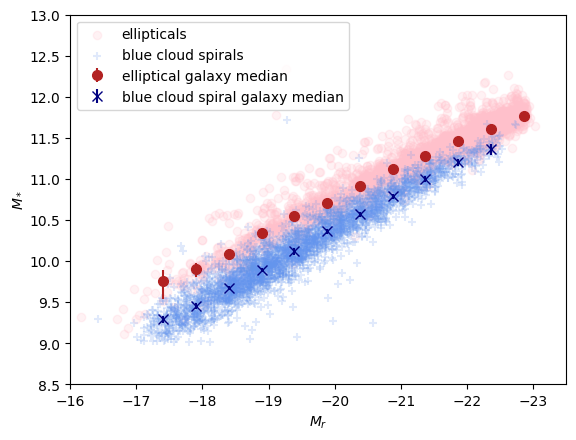

In [19]:
plt.scatter(ellipticals['rabsmag'], ellipticals['sphd_M_star'], marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(spirals['rabsmag'][spirals['CMD_class'] == 1], 
            spirals['M90_disk'][spirals['CMD_class']==1], marker='+', color='cornflowerblue', label='blue cloud spirals', alpha=0.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_*$')
plt.xlim(-16, -23.5)
plt.ylim(8.5,13)
plt.legend()


sp_mstar = med_err(s_mstar)
ep_mstar = med_err(e_mstar)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=ep_mstar[inf_bars][:,0]-9, uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='blue cloud spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=sp_mstar[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')



plt.legend()

plt.savefig(plot_dir + 'Mr_Mstar_ellipticals_bluespirals_scatter.png')

### Mtot vs Mr by CMD for spirals

In [50]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)
pts = (bins[:-1] + bins [1:]) / 2

red_spirals = spirals[spirals['CMD_class'] ==3]

e_mstar = []
s_mstar = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(ellipticals['Mvir'][ellipticals['rabsmag'] <= mag_lim])
        s_mstar.append(red_spirals['M_R90'][red_spirals['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mstar.append(ellipticals['Mvir'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)])
        
        s_mstar.append(red_spirals['M_R90'][np.logical_and(red_spirals['rabsmag'] <= mag_lim, 
                                                                         red_spirals['rabsmag'] > lower_lim)])


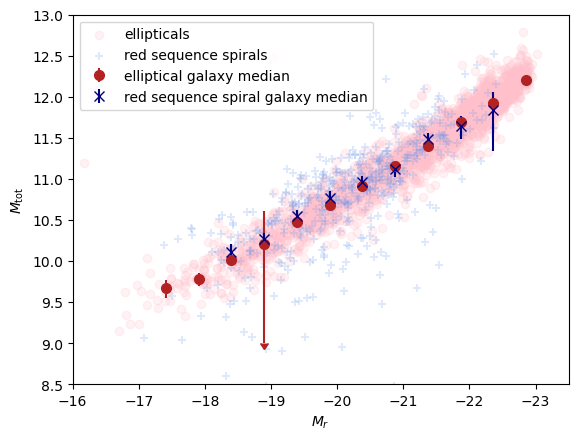

In [51]:
plt.scatter(ellipticals['rabsmag'], ellipticals['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(spirals['rabsmag'][spirals['CMD_class'] == 3], 
            spirals['M_R90'][spirals['CMD_class']==3], marker='+', color='cornflowerblue', label='red sequence spirals', alpha=0.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_{\rm tot}$')
plt.xlim(-16, -23.5)
plt.ylim(8.5,13)
plt.legend()


sp_mstar = med_err(s_mstar)
ep_mstar = med_err(e_mstar)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9,
             # yerr=2,
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='red sequence spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], 
             yerr=sp_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')



plt.legend()
plt.savefig(plot_dir + 'Mr_Mtot_ellipticals_redspirals_scatter.png')

In [52]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)
pts = (bins[:-1] + bins [1:]) / 2

green_spirals = spirals[spirals['CMD_class'] ==2]

e_mstar = []
s_mstar = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(ellipticals['Mvir'][ellipticals['rabsmag'] <= mag_lim])
        s_mstar.append(green_spirals['M_R90'][green_spirals['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mstar.append(ellipticals['Mvir'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)])
        
        s_mstar.append(green_spirals['M_R90'][np.logical_and(green_spirals['rabsmag'] <= mag_lim, 
                                                                         green_spirals['rabsmag'] > lower_lim)])

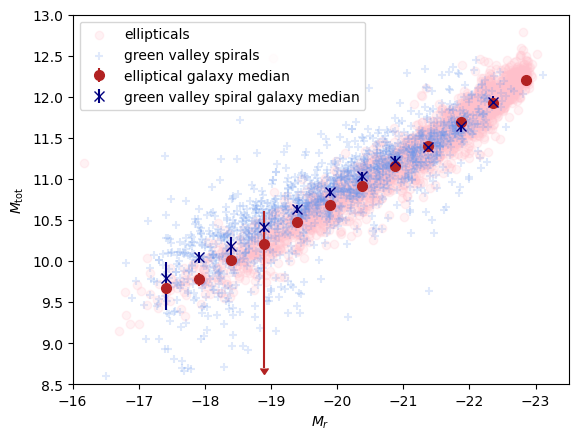

In [53]:
plt.scatter(ellipticals['rabsmag'], ellipticals['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(spirals['rabsmag'][spirals['CMD_class'] == 2], 
            spirals['M_R90'][spirals['CMD_class']==2], marker='+', color='cornflowerblue', label='green valley spirals', alpha=0.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_{\rm tot}$')
plt.xlim(-16, -23.5)
plt.ylim(8.5,13)
plt.legend()


sp_mstar = med_err(s_mstar)
ep_mstar = med_err(e_mstar)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=ep_mstar[inf_bars][:,0]-8.7, uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='green valley spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=sp_mstar[inf_bars][:,0]-8.7, uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')



plt.legend()

plt.savefig(plot_dir + 'Mr_Mtot_ellipticals_greenspirals_scatter.png')

In [54]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)
pts = (bins[:-1] + bins [1:]) / 2

blue_spirals = spirals[spirals['CMD_class'] ==1]

e_mstar = []
s_mstar = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(ellipticals['Mvir'][ellipticals['rabsmag'] <= mag_lim])
        s_mstar.append(blue_spirals['M_R90'][blue_spirals['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mstar.append(ellipticals['Mvir'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)])
        
        s_mstar.append(blue_spirals['M_R90'][np.logical_and(blue_spirals['rabsmag'] <= mag_lim, 
                                                                         blue_spirals['rabsmag'] > lower_lim)])

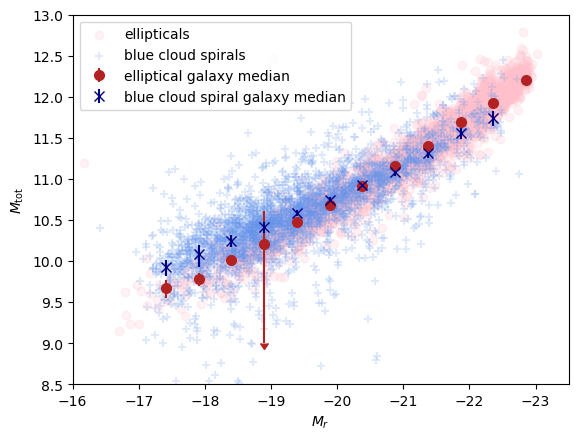

In [55]:
plt.scatter(ellipticals['rabsmag'], ellipticals['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(spirals['rabsmag'][spirals['CMD_class'] == 1], 
            spirals['M_R90'][spirals['CMD_class']==1], marker='+', color='cornflowerblue', label='blue cloud spirals', alpha=0.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_{\rm tot}$')
plt.xlim(-16, -23.5)
plt.ylim(8.5,13)
plt.legend()


sp_mstar = med_err(s_mstar)
ep_mstar = med_err(e_mstar)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=ep_mstar[inf_bars][:,0]-9, uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='blue cloud spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=sp_mstar[inf_bars][:,0], uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')



plt.legend()

plt.savefig(plot_dir + 'Mr_Mtot_ellipticals_bluespirals_scatter.png')

### Mtot vs Mstar by CMD for spirals

In [82]:
bins = np.linspace(np.min([np.min(spirals['M90_disk']), np.min(ellipticals['sphd_M_star'])]),
                  # np.max([np.max(spirals['M90_disk']), np.max(ellipticals['sum_M_star'])]), 
                   14,
                   15)
pts = (bins[:-1] + bins [1:]) / 2

red_spirals = spirals[spirals['CMD_class'] ==3]

e_mstar = []
s_mstar = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(ellipticals['Mvir'][ellipticals['sphd_M_star'] <= mag_lim])
        s_mstar.append(red_spirals['M_R90'][red_spirals['M90_disk'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mstar.append(ellipticals['Mvir'][np.logical_and(ellipticals['sphd_M_star'] <= mag_lim, 
                                                                         ellipticals['sphd_M_star'] > lower_lim)])
        
        s_mstar.append(red_spirals['M_R90'][np.logical_and(red_spirals['M90_disk'] <= mag_lim, 
                                                                         red_spirals['M90_disk'] > lower_lim)])


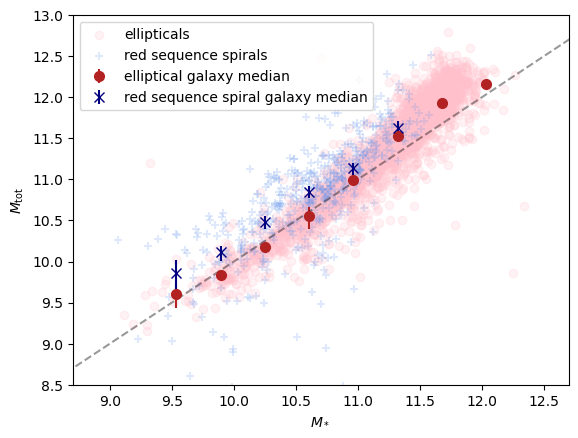

In [83]:
plt.scatter(ellipticals['sphd_M_star'], ellipticals['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(spirals['M90_disk'][spirals['CMD_class'] == 3], 
            spirals['M_R90'][spirals['CMD_class']==3], marker='+', color='cornflowerblue', label='red sequence spirals', alpha=0.2)

plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{\rm tot}$')
plt.xlim(8.7, 12.7)
plt.ylim(8.5,13)
plt.legend()


sp_mstar = med_err(s_mstar)
ep_mstar = med_err(e_mstar)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9,
             # yerr=2,
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='red sequence spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], 
             yerr=sp_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


plt.plot([8.5,13],[8.5,13], linestyle='--', color='k', alpha=0.4)
plt.legend()
plt.savefig(plot_dir + 'Mstar_Mtot_ellipticals_redspirals_scatter.png')

In [84]:
bins = np.linspace(np.min([np.min(spirals['M90_disk']), np.min(ellipticals['sphd_M_star'])]),
                  # np.max([np.max(spirals['M90_disk']), np.max(ellipticals['sum_M_star'])]), 
                   14,
                   15)
pts = (bins[:-1] + bins [1:]) / 2

green_spirals = spirals[spirals['CMD_class'] ==2]

e_mstar = []
s_mstar = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(ellipticals['Mvir'][ellipticals['sphd_M_star'] <= mag_lim])
        s_mstar.append(green_spirals['M_R90'][green_spirals['M90_disk'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mstar.append(ellipticals['Mvir'][np.logical_and(ellipticals['sphd_M_star'] <= mag_lim, 
                                                                         ellipticals['sphd_M_star'] > lower_lim)])
        
        s_mstar.append(green_spirals['M_R90'][np.logical_and(green_spirals['M90_disk'] <= mag_lim, 
                                                                         green_spirals['M90_disk'] > lower_lim)])


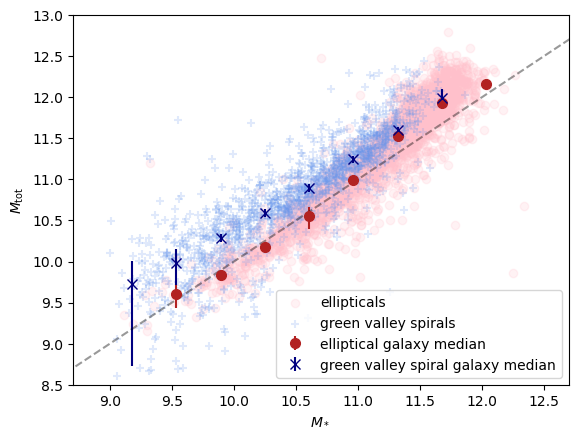

In [85]:
plt.scatter(ellipticals['sphd_M_star'], ellipticals['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(spirals['M90_disk'][spirals['CMD_class'] == 2], 
            spirals['M_R90'][spirals['CMD_class']==2], marker='+', color='cornflowerblue', label='green valley spirals', alpha=0.2)

plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{\rm tot}$')
plt.xlim(8.7, 12.7)
plt.ylim(8.5,13)
plt.legend()


sp_mstar = med_err(s_mstar)
ep_mstar = med_err(e_mstar)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9,
             # yerr=2,
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='green valley spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], 
             yerr=sp_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')

plt.plot([8.5,13],[8.5,13], linestyle='--', color='k', alpha=0.4)


plt.legend()
plt.savefig(plot_dir + 'Mstar_Mtot_ellipticals_greenspirals_scatter.png')

In [86]:
bins = np.linspace(np.min([np.min(spirals['M90_disk']), np.min(ellipticals['sphd_M_star'])]),
                  # np.max([np.max(spirals['M90_disk']), np.max(ellipticals['sum_M_star'])]), 
                   14,
                   15)
pts = (bins[:-1] + bins [1:]) / 2

blue_spirals = spirals[spirals['CMD_class'] ==1]

e_mstar = []
s_mstar = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(ellipticals['Mvir'][ellipticals['sphd_M_star'] <= mag_lim])
        s_mstar.append(blue_spirals['M_R90'][blue_spirals['M90_disk'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mstar.append(ellipticals['Mvir'][np.logical_and(ellipticals['sphd_M_star'] <= mag_lim, 
                                                                         ellipticals['sphd_M_star'] > lower_lim)])
        
        s_mstar.append(blue_spirals['M_R90'][np.logical_and(blue_spirals['M90_disk'] <= mag_lim, 
                                                                         blue_spirals['M90_disk'] > lower_lim)])


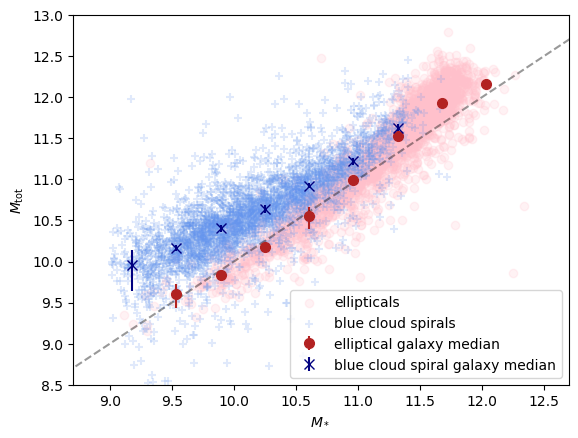

In [87]:
plt.scatter(ellipticals['sphd_M_star'], ellipticals['Mvir'], marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(spirals['M90_disk'][spirals['CMD_class'] == 1], 
            spirals['M_R90'][spirals['CMD_class']==1], marker='+', color='cornflowerblue', label='blue cloud spirals', alpha=0.2)

plt.xlabel(r'$M_*$')
plt.ylabel(r'$M_{\rm tot}$')
plt.xlim(8.7, 12.7)
plt.ylim(8.5,13)
plt.legend()


sp_mstar = med_err(s_mstar)
ep_mstar = med_err(e_mstar)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9,
             # yerr=2,
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='blue cloud spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], 
             yerr=sp_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


plt.plot([8.5,13],[8.5,13], linestyle='--', color='k', alpha=0.4)

plt.legend()
plt.savefig(plot_dir + 'Mstar_Mtot_ellipticals_bluespirals_scatter.png')

### Mtot vs Mstar

In [34]:
bins = np.linspace(np.min([np.min(spirals['M_R90']), np.min(ellipticals['Mvir'])]),
                  np.max([np.max(spirals['M_R90']), np.max(ellipticals['Mvir'])]), 
                   14,
                   15)
pts = (bins[:-1] + bins [1:]) / 2

red_spirals = spirals[spirals['CMD_class'] ==3]

e_mstar = []
s_mstar = []


xp = [8.15,13]
fp = [11, 14]


rm_outliers = ellipticals[ellipticals['sphd_M_star'] < np.interp(ellipticals['Mvir'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(rm_outliers['sphd_M_star'][rm_outliers['Mvir'] <= mag_lim])
        s_mstar.append(red_spirals['M90_disk'][red_spirals['M_R90'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mstar.append(rm_outliers['sphd_M_star'][np.logical_and(rm_outliers['Mvir'] <= mag_lim, 
                                                                         rm_outliers['Mvir'] > lower_lim)])
        
        s_mstar.append(red_spirals['M90_disk'][np.logical_and(red_spirals['M_R90'] <= mag_lim, 
                                                                         red_spirals['M_R90'] > lower_lim)])


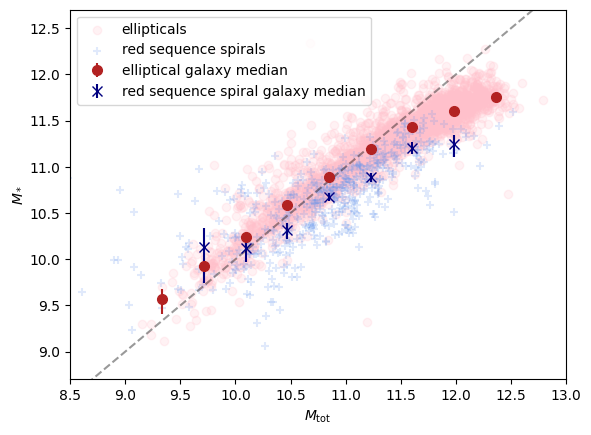

In [38]:
plt.scatter(ellipticals['Mvir'], ellipticals['sphd_M_star'], marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(spirals['M_R90'][spirals['CMD_class'] == 3], 
            spirals['M90_disk'][spirals['CMD_class']==3], marker='+', color='cornflowerblue', label='red sequence spirals', alpha=0.2)

plt.ylabel(r'$M_*$')
plt.xlabel(r'$M_{\rm tot}$')
plt.ylim(8.7, 12.7)
plt.xlim(8.5,13)
plt.legend()


sp_mstar = med_err(s_mstar)
ep_mstar = med_err(e_mstar)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9,
             # yerr=2,
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='red sequence spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], 
             yerr=sp_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


plt.plot([8.5,13],[8.5,13], linestyle='--', color='k', alpha=0.4)


plt.legend()
plt.savefig(plot_dir + 'Mtot_Mstar_ellipticals_redspirals_scatter.png')

In [39]:
bins = np.linspace(np.min([np.min(spirals['M_R90']), np.min(ellipticals['Mvir'])]),
                  np.max([np.max(spirals['M_R90']), np.max(ellipticals['Mvir'])]), 
                   14,
                   15)
pts = (bins[:-1] + bins [1:]) / 2

green_spirals = spirals[spirals['CMD_class'] ==2]

e_mstar = []
s_mstar = []


xp = [8.15,13]
fp = [11, 14]


rm_outliers = ellipticals[ellipticals['sphd_M_star'] < np.interp(ellipticals['Mvir'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(rm_outliers['sphd_M_star'][rm_outliers['Mvir'] <= mag_lim])
        s_mstar.append(green_spirals['M90_disk'][green_spirals['M_R90'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mstar.append(rm_outliers['sphd_M_star'][np.logical_and(rm_outliers['Mvir'] <= mag_lim, 
                                                                         rm_outliers['Mvir'] > lower_lim)])
        
        s_mstar.append(green_spirals['M90_disk'][np.logical_and(green_spirals['M_R90'] <= mag_lim, 
                                                                         green_spirals['M_R90'] > lower_lim)])


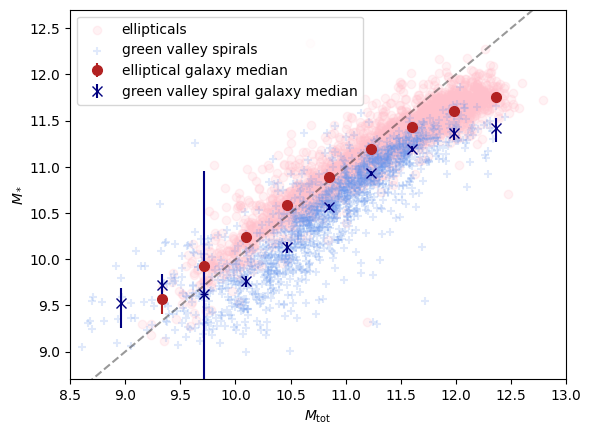

In [41]:
plt.scatter(ellipticals['Mvir'], ellipticals['sphd_M_star'], marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(spirals['M_R90'][spirals['CMD_class'] == 2], 
            spirals['M90_disk'][spirals['CMD_class']==2], marker='+', color='cornflowerblue', label='green valley spirals', alpha=0.2)

plt.ylabel(r'$M_*$')
plt.xlabel(r'$M_{\rm tot}$')
plt.ylim(8.7, 12.7)
plt.xlim(8.5,13)
plt.legend()


sp_mstar = med_err(s_mstar)
ep_mstar = med_err(e_mstar)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9,
             # yerr=2,
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='green valley spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], 
             yerr=sp_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


plt.plot([8.5,13],[8.5,13], linestyle='--', color='k', alpha=0.4)


plt.legend()
plt.savefig(plot_dir + 'Mtot_Mstar_ellipticals_greenspirals_scatter.png')

In [42]:
bins = np.linspace(np.min([np.min(spirals['M_R90']), np.min(ellipticals['Mvir'])]),
                  np.max([np.max(spirals['M_R90']), np.max(ellipticals['Mvir'])]), 
                   14,
                   15)
pts = (bins[:-1] + bins [1:]) / 2

blue_spirals = spirals[spirals['CMD_class'] ==1]

e_mstar = []
s_mstar = []


xp = [8.15,13]
fp = [11, 14]


rm_outliers = ellipticals[ellipticals['sphd_M_star'] < np.interp(ellipticals['Mvir'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(rm_outliers['sphd_M_star'][rm_outliers['Mvir'] <= mag_lim])
        s_mstar.append(blue_spirals['M90_disk'][blue_spirals['M_R90'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mstar.append(rm_outliers['sphd_M_star'][np.logical_and(rm_outliers['Mvir'] <= mag_lim, 
                                                                         rm_outliers['Mvir'] > lower_lim)])
        
        s_mstar.append(blue_spirals['M90_disk'][np.logical_and(blue_spirals['M_R90'] <= mag_lim, 
                                                                         blue_spirals['M_R90'] > lower_lim)])


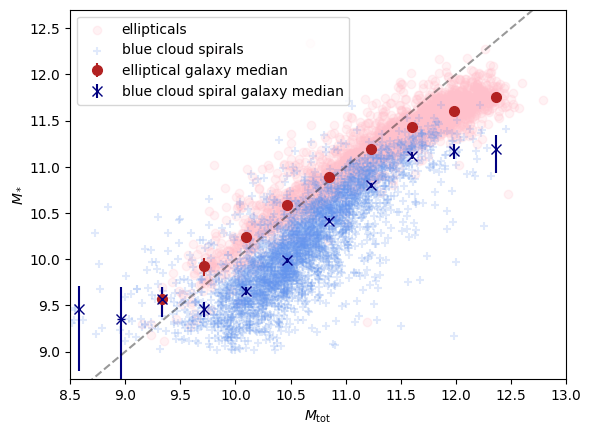

In [43]:
plt.scatter(ellipticals['Mvir'], ellipticals['sphd_M_star'], marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(spirals['M_R90'][spirals['CMD_class'] == 1], 
            spirals['M90_disk'][spirals['CMD_class']==1], marker='+', color='cornflowerblue', label='blue cloud spirals', alpha=0.2)

plt.ylabel(r'$M_*$')
plt.xlabel(r'$M_{\rm tot}$')
plt.ylim(8.7, 12.7)
plt.xlim(8.5,13)
plt.legend()


sp_mstar = med_err(s_mstar)
ep_mstar = med_err(e_mstar)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9,
             # yerr=2,
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='blue cloud spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], 
             yerr=sp_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


plt.plot([8.5,13],[8.5,13], linestyle='--', color='k', alpha=0.4)


plt.legend()
plt.savefig(plot_dir + 'Mtot_Mstar_ellipticals_bluespirals_scatter.png')

### M*/Mtot binned by Mr, CMD split

In [11]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 10)
pts = (bins[:-1] + bins [1:]) / 2

red_spirals = spirals[spirals['CMD_class'] ==3]

e_mstar = []
s_mstar = []

# rm_outliers = ellipticals[ellipticals['sphd_M_star'] < np.interp(ellipticals['rabsmag'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(10**(ellipticals['sphd_M_star'][ellipticals['rabsmag'] <= mag_lim] 
                       - ellipticals['Mvir'][ellipticals['rabsmag'] <= mag_lim]))
        s_mstar.append(10**(red_spirals['M90_disk'][red_spirals['rabsmag'] <= mag_lim]
                      - red_spirals['M_R90'][red_spirals['rabsmag'] <= mag_lim]))

    else:
        lower_lim = bins[i]
        e_mstar.append(10**(ellipticals['sphd_M_star'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)]
                      - ellipticals['Mvir'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)]))
        
        s_mstar.append(10**(red_spirals['M90_disk'][np.logical_and(red_spirals['rabsmag'] <= mag_lim, 
                                                                         red_spirals['rabsmag'] > lower_lim)]
                      - red_spirals['M_R90'][np.logical_and(red_spirals['rabsmag'] <= mag_lim, 
                                                                         red_spirals['rabsmag'] > lower_lim)]))


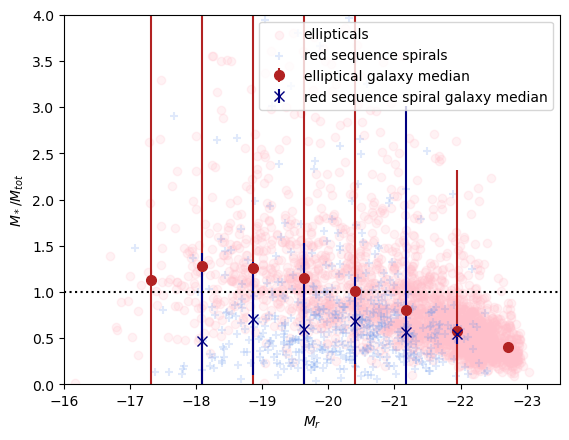

In [12]:
plt.scatter(ellipticals['rabsmag'],10**(ellipticals['sphd_M_star']-ellipticals['Mvir']), marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(red_spirals['rabsmag'], 
            10**(red_spirals['M90_disk']-red_spirals['M_R90']), marker='+', color='cornflowerblue', label='red sequence spirals', alpha=0.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_*/M_{tot}$')
plt.xlim(-16, -23.5)
plt.ylim(0,4)
plt.legend()


sp_mstar = med_err(s_mstar, False, False)
ep_mstar = med_err(e_mstar, False, False)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9,
             # yerr=2,
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='red sequence spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], 
             yerr=sp_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


# plt.plot([-23,-16],[13, 10.5])
plt.axhline(1, color='k', linestyle=':')

plt.legend()
plt.savefig(plot_dir + 'Mr_MstarMtot_ellipticals_redspirals_scatter.png')

In [17]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 10)
pts = (bins[:-1] + bins [1:]) / 2

green_spirals = spirals[spirals['CMD_class'] ==2]

e_mstar = []
s_mstar = []

# rm_outliers = ellipticals[ellipticals['sphd_M_star'] < np.interp(ellipticals['rabsmag'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(10**(ellipticals['sphd_M_star'][ellipticals['rabsmag'] <= mag_lim] 
                       - ellipticals['Mvir'][ellipticals['rabsmag'] <= mag_lim]))
        s_mstar.append(10**(green_spirals['M90_disk'][green_spirals['rabsmag'] <= mag_lim]
                      - green_spirals['M_R90'][green_spirals['rabsmag'] <= mag_lim]))

    else:
        lower_lim = bins[i]
        e_mstar.append(10**(ellipticals['sphd_M_star'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)]
                      - ellipticals['Mvir'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)]))
        
        s_mstar.append(10**(green_spirals['M90_disk'][np.logical_and(green_spirals['rabsmag'] <= mag_lim, 
                                                                         green_spirals['rabsmag'] > lower_lim)]
                      - green_spirals['M_R90'][np.logical_and(green_spirals['rabsmag'] <= mag_lim, 
                                                                         green_spirals['rabsmag'] > lower_lim)]))


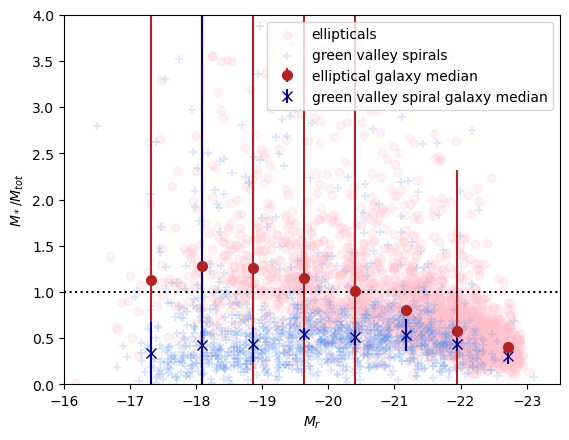

In [18]:
plt.scatter(ellipticals['rabsmag'],10**(ellipticals['sphd_M_star']-ellipticals['Mvir']), marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(green_spirals['rabsmag'], 
            10**(green_spirals['M90_disk']-green_spirals['M_R90']), marker='+', color='cornflowerblue', label='green valley spirals', alpha=0.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_*/M_{tot}$')
plt.xlim(-16, -23.5)
plt.ylim(0,4)
plt.legend()


sp_mstar = med_err(s_mstar, False, False)
ep_mstar = med_err(e_mstar, False, False)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9,
             # yerr=2,
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='green valley spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], 
             yerr=sp_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


# plt.plot([-23,-16],[13, 10.5])

plt.axhline(1, color='k', linestyle=':')


plt.legend()
plt.savefig(plot_dir + 'Mr_MstarMtot_ellipticals_greenspirals_scatter.png')

In [19]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                  np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 10)
pts = (bins[:-1] + bins [1:]) / 2

blue_spirals = spirals[spirals['CMD_class'] ==1]

e_mstar = []
s_mstar = []

# rm_outliers = ellipticals[ellipticals['sphd_M_star'] < np.interp(ellipticals['rabsmag'],xp,fp)]

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mstar.append(10**(ellipticals['sphd_M_star'][ellipticals['rabsmag'] <= mag_lim] 
                       - ellipticals['Mvir'][ellipticals['rabsmag'] <= mag_lim]))
        s_mstar.append(10**(blue_spirals['M90_disk'][blue_spirals['rabsmag'] <= mag_lim]
                      - blue_spirals['M_R90'][blue_spirals['rabsmag'] <= mag_lim]))

    else:
        lower_lim = bins[i]
        e_mstar.append(10**(ellipticals['sphd_M_star'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)]
                      - ellipticals['Mvir'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)]))
        
        s_mstar.append(10**(blue_spirals['M90_disk'][np.logical_and(blue_spirals['rabsmag'] <= mag_lim, 
                                                                         blue_spirals['rabsmag'] > lower_lim)]
                      - blue_spirals['M_R90'][np.logical_and(blue_spirals['rabsmag'] <= mag_lim, 
                                                                         blue_spirals['rabsmag'] > lower_lim)]))


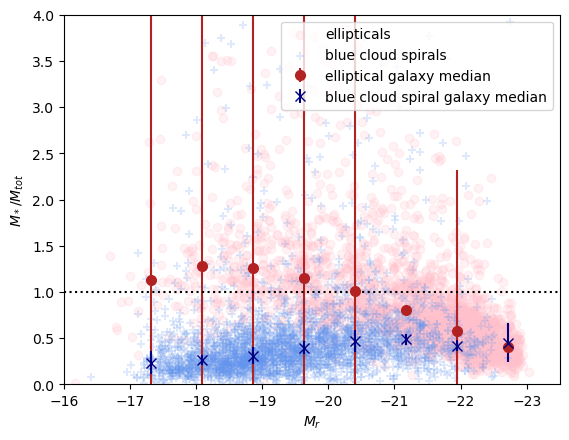

In [20]:
plt.scatter(ellipticals['rabsmag'],10**(ellipticals['sphd_M_star']-ellipticals['Mvir']), marker='o', color='pink', label='ellipticals', alpha=0.2)
plt.scatter(blue_spirals['rabsmag'], 
            10**(blue_spirals['M90_disk']-blue_spirals['M_R90']), marker='+', color='cornflowerblue', label='blue cloud spirals', alpha=0.2)

plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_*/M_{tot}$')
plt.xlim(-16, -23.5)
plt.ylim(0,4)
plt.legend()


sp_mstar = med_err(s_mstar, False, False)
ep_mstar = med_err(e_mstar, False, False)

inf_bars = np.where(ep_mstar == np.inf)[0]
ep_mstar[inf_bars][:,0]
plt.errorbar(pts, ep_mstar[:,0], color='firebrick', yerr=[ep_mstar[:,1] ,ep_mstar[:,2]], 
             marker='o', label='elliptical galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], 
             yerr=ep_mstar[inf_bars][:,0]-9,
             # yerr=2,
             uplims=True,
             color='firebrick', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], ep_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),ep_mstar[inf_bars][:,2]],
            linestyle='none', color='firebrick', mfc='none', mec='none')

inf_bars = np.where(sp_mstar == np.inf)[0]
sp_mstar[inf_bars][:,0]
plt.errorbar(pts, sp_mstar[:,0], color='navy', yerr=[sp_mstar[:,1] ,sp_mstar[:,2]], 
             marker='x', label='blue cloud spiral galaxy median',linestyle='none', markersize=7,)
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], 
             yerr=sp_mstar[inf_bars][:,0], 
             uplims=True,
             color='navy', linestyle='none', capsize=3, mfc='none', mec='none')
plt.errorbar(pts[inf_bars], sp_mstar[inf_bars][:,0], yerr=[np.zeros(len(inf_bars)),sp_mstar[inf_bars][:,2]],
            linestyle='none', color='navy', mfc='none', mec='none')


# plt.plot([-23,-16],[13, 10.5])
plt.axhline(1, color='k', linestyle=':')


plt.legend()
plt.savefig(plot_dir + 'Mr_MstarMtot_ellipticals_bluespirals_scatter.png')

### M* vs Mr with fixed M/L's

### gas vs Mstar

In [90]:
HI_ellipticals = ellipticals[ellipticals['logHI']>0]

In [95]:
HI_ellipticals['logHI','sphd_M_star']

logHI,sphd_M_star
float64,float64
8.994941711425781,10.805040039869427
9.167349815368652,10.736125834544632
9.507925987243652,11.181045763238117
10.230278968811035,11.444050951808606
9.595641136169434,10.855818361013595
9.617752075195312,10.613606712449876
9.665602684020996,11.294111345625568
10.261069297790527,10.97481524578048
9.482563972473145,10.8359214050032


In [96]:
HI_ellipticals[HI_ellipticals['logHI'] > HI_ellipticals['sphd_M_star']]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64

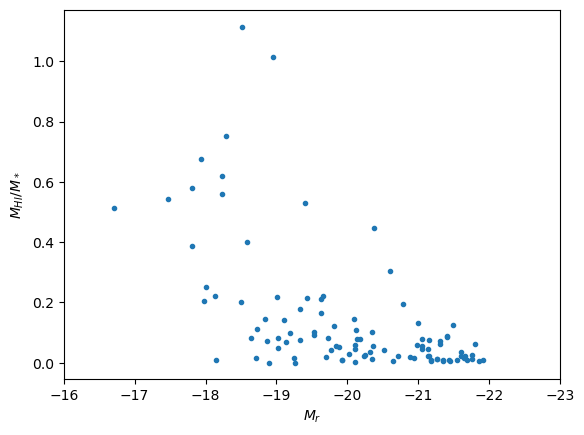

In [109]:
plt.scatter(HI_ellipticals['rabsmag'],10**(HI_ellipticals['logHI'] - HI_ellipticals['sphd_M_star']), marker='.')
# plt.scatter(ellipticals['rabsmag'], ellipticals['sphd_M_star'], alpha=0.2)
plt.xlim(-16,-23)
plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_{HI}/M_*$')
plt.savefig(plot_dir + 'Mr_MHIMstar.png')

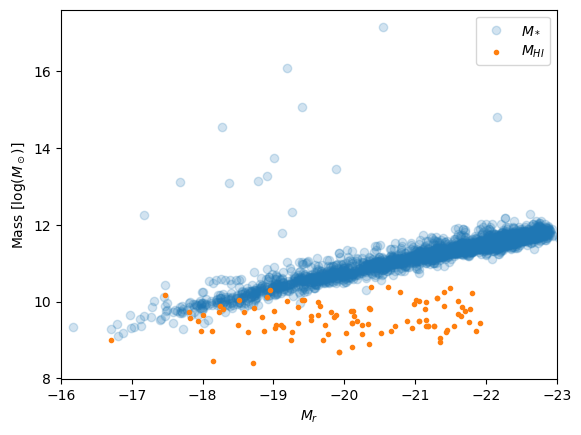

In [108]:
# plt.scatter(HI_ellipticals['rabsmag'],10**(HI_ellipticals['logHI'] - HI_ellipticals['sphd_M_star']), marker='.')
plt.scatter(ellipticals['rabsmag'], ellipticals['sphd_M_star'], alpha=0.2, label=r'$M_*$')
plt.scatter(HI_ellipticals['rabsmag'], HI_ellipticals['logHI'], marker='.', label=r'$M_{HI}$')
plt.xlim(-16,-23)
plt.xlabel(r'$M_r$')
plt.ylabel(r'Mass $[\log (M_\odot)]$')
plt.legend()

In [110]:
HI_spirals = spirals[spirals['logHI'] > 0]

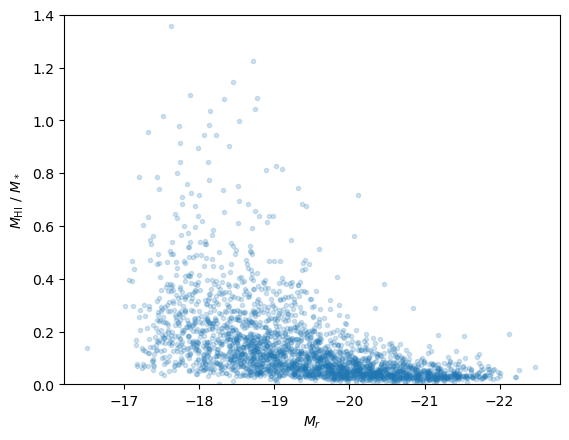

In [121]:
plt.scatter(HI_spirals['rabsmag'], 10**(HI_spirals['logHI_R90'] - HI_spirals['M90_disk']), marker='.', alpha=0.2)
plt.xlim(-16.2, -22.8)
plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_{\rm HI}\ /\ M_*$')
plt.ylim(0,1.4)
plt.savefig(plot_dir + 'Mr_MHIMstar_spirals_scatter.png')

(0.0, 2.0)

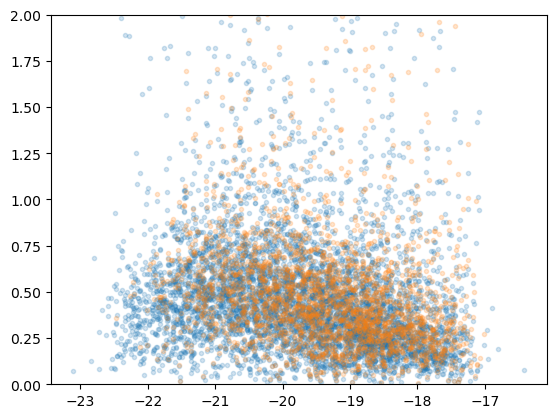

In [137]:
plt.scatter(spirals['rabsmag'], 10**(spirals['M90_disk'] - spirals['M_R90']), marker='.', alpha=0.2)
plt.scatter(HI_spirals['rabsmag'], (10**HI_spirals['M90_disk'] + 10**HI_spirals['logHI_R90'])/ 10**HI_spirals['M_R90'], marker='.', alpha=0.2)
plt.ylim(0,2)

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\ '
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\ '
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_33281/1203792803.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Visible mass $[\log (M_\odot)]$')
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_33281/1203792803.py:8: SyntaxWarning: invalid escape sequence '\ '
  plt.ylabel('Total mass within $R_{90}\ [\log (M_\odot)]$')


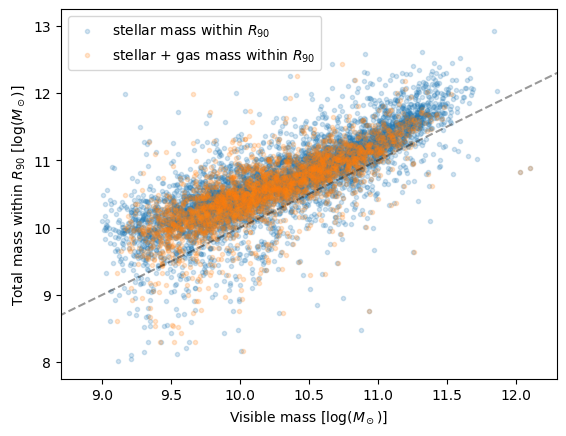

In [148]:
plt.scatter(spirals['M90_disk'], spirals['M_R90'], marker='.', label='stellar mass within $R_{90}$', alpha=0.2)
plt.scatter(np.log10(10**HI_spirals['M90_disk'] + 10**HI_spirals['logHI_R90']), HI_spirals['M_R90'], 
            marker='.', label='stellar + gas mass within $R_{90}$', alpha=0.2)
plt.plot([8,13],[8,13], color='k', alpha=0.4, linestyle='--')
plt.xlim(8.7,12.3)
plt.legend()
plt.xlabel('Visible mass $[\log (M_\odot)]$')
plt.ylabel('Total mass within $R_{90}\ [\log (M_\odot)]$')
plt.savefig(plot_dir + 'Mvis_Mtot_spirals_GQP.png')

In [ ]:
10**HI_spirals['M90_disk'] + 10**HI_spirals['logHI_R90'] 

In [136]:
HI_spirals['M90_disk', 'logHI_R90', 'M_R90']

M90_disk,logHI_R90,M_R90
float64,float64,float64
10.054323200255043,9.372622413684429,10.435568445972814
10.124313484194262,9.18949974524763,10.54751608303024
10.546935338970071,9.335680626404208,10.876823345049761
9.918768524805014,8.949839609021893,10.512850735957437
10.47990656722755,9.26583678602232,10.845328373310418
10.670399862328992,8.991504564168537,10.8690529846641
10.142494114170608,9.301640665240676,10.450615947344364
9.973597048381457,9.101614827924395,10.414080250676475
10.559994215746384,9.6354180804539,11.19672506448625


### M* vs Mr spirals and ellipticals, slopes change at Mr = -20

In [80]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                   np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]),
                   15)
pts = (bins[1:] + bins[:-1])/2

e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(ellipticals['sum_M_star'][ellipticals['rabsmag'] <= mag_lim])
        s_mratio.append(spirals['M90_disk'][spirals['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(ellipticals['sum_M_star'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)])
        
        s_mratio.append(spirals['M90_disk'][np.logical_and(spirals['rabsmag'] <= mag_lim, 
                                                                         spirals['rabsmag'] > lower_lim)])

sp_mratio = med_err(s_mratio)
ep_mratio = med_err(e_mratio)

In [68]:
bright = pts < -20
faint = pts > -20

In [69]:
sp_res_bright = scipy.optimize.minimize(chi2_mass_lum,
                                 [-0.3, -0.4],
                                  method='Powell',
                              args=(pts[bright][2:],sp_mratio[bright][2:,0], sp_mratio[bright][2:,2])
                             )
sp_res_faint = scipy.optimize.minimize(chi2_mass_lum,
                                 [-0.3, -0.4],
                                  method='Powell',
                              args=(pts[faint][:-1],sp_mratio[faint][:-1,0], sp_mratio[faint][:-1,2])
                             )

ep_res_bright = scipy.optimize.minimize(chi2_mass_lum,
                                 [-0.3, -0.4],
                                  method='Powell',
                              args=(pts[bright][2:],ep_mratio[bright][2:,0], ep_mratio[bright][2:,2])
                             )
ep_res_faint = scipy.optimize.minimize(chi2_mass_lum,
                                 [-0.3, -0.4],
                                  method='Powell',
                              args=(pts[faint][:-1],ep_mratio[faint][:-1,0], ep_mratio[faint][:-1,2])
                             )

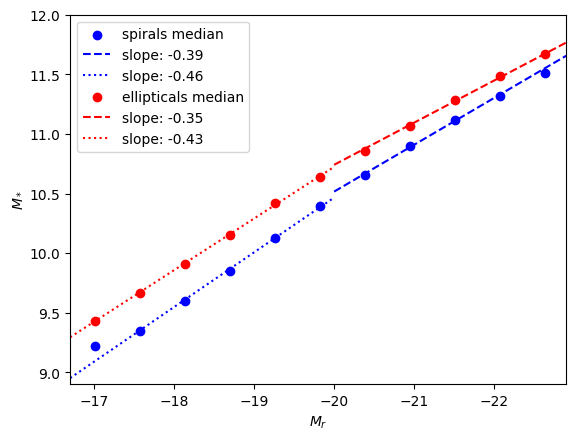

In [76]:
plt.scatter(pts, sp_mratio[:,0], color='b', label='spirals median')

xs_1 = np.linspace(-16.7, -20, 50)
xs_2 = np.linspace(-20,-22.9, 50)
plt.plot(xs_2, sp_res_bright.x[0]*xs_2 + sp_res_bright.x[1], color='b', linestyle = '--', label='slope: {:.2f}'.format(sp_res_bright.x[0]))
plt.plot(xs_1, sp_res_faint.x[0]*xs_1 + sp_res_faint.x[1], color='b', linestyle=':', label='slope: {:.2f}'.format(sp_res_faint.x[0]))

plt.scatter(pts, ep_mratio[:,0], color='r', label='ellipticals median')
plt.plot(xs_2, ep_res_bright.x[0]*xs_2 + ep_res_bright.x[1], color='r', linestyle = '--', label='slope: {:.2f}'.format(ep_res_bright.x[0]))
plt.plot(xs_1, ep_res_faint.x[0]*xs_1 + ep_res_faint.x[1], color='r', linestyle=':', label='slope: {:.2f}'.format(ep_res_faint.x[0]))

plt.ylim(8.9,12)
plt.xlim(-16.7, -22.9)
plt.legend()
plt.xlabel(r'$M_r$')
plt.ylabel(r'$M_*$')

plt.savefig(plot_dir + 'Mr_Mstar_2slopes.png')

In [98]:
bins = np.linspace(np.min([np.min(spirals['rabsmag']), np.min(ellipticals['rabsmag'])]),
                   np.max([np.max(spirals['rabsmag']), np.max(ellipticals['rabsmag'])]),
                   20)
pts = (bins[1:] + bins[:-1])/2

e_mratio = []
s_mratio = []

for i in range(len(pts)):
    mag_lim = bins[i+1]
    if i == 0:
        e_mratio.append(ellipticals['sum_M_star'][ellipticals['rabsmag'] <= mag_lim])
        s_mratio.append(spirals['M90_disk'][spirals['rabsmag'] <= mag_lim])

    else:
        lower_lim = bins[i]
        e_mratio.append(ellipticals['sum_M_star'][np.logical_and(ellipticals['rabsmag'] <= mag_lim, 
                                                                         ellipticals['rabsmag'] > lower_lim)])
        
        s_mratio.append(spirals['M90_disk'][np.logical_and(spirals['rabsmag'] <= mag_lim, 
                                                                         spirals['rabsmag'] > lower_lim)])

sp_mratio = med_err(s_mratio)
ep_mratio = med_err(e_mratio)

In [100]:
ep_mratio

array([[        nan,         nan,         nan],
       [        nan,         nan,         nan],
       [11.77061059,  0.06440469,  0.05607556],
       [11.66549372,  0.02827593,  0.02654694],
       [11.51502804,         inf,  2.29930892],
       [11.37223859,  0.02551549,  0.02409924],
       [11.20683089,  0.02793573,  0.02624687],
       [11.06521915,  0.03522165,  0.03257819],
       [10.91227074,  0.03599524,  0.03323888],
       [10.73405393,         inf,  4.76650578],
       [10.59338313,  0.03936801,  0.03609409],
       [10.4231905 ,  0.04635609,  0.04188184],
       [10.2545126 ,  0.0481592 ,  0.04334789],
       [10.02906663,  0.05639727,  0.04990816],
       [ 9.87324621,  0.07665513,  0.06513338],
       [ 9.70070301,  0.10114918,  0.08198454],
       [ 9.52616464,  0.19502811,  0.13410626],
       [        nan,         nan,         nan],
       [        nan,         nan,         nan]])

In [105]:
sp_res = scipy.optimize.minimize(chi2_mass_lum_break,
                                 [-0.4, 3, -0.5, 5, -21],
                                  method='Powell',
                              args=(pts[2:-3],sp_mratio[2:-3,0], sp_mratio[2:-3,2])
                             )

In [106]:
sp_res

 message: NaN result encountered.
 success: False
  status: 3
     fun: 0.0
       x: [       nan        nan        nan        nan        nan]
     nit: 2
   direc: [[ 1.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]]
    nfev: 32

In [115]:
ep_res = scipy.optimize.minimize(chi2_mass_lum_break,
                                 [-0.35, 3, -0.43, 5, -18],
                                  method='Powell',
                              args=(pts[2:-2],ep_mratio[2:-2,0], ep_mratio[2:-2,2])
                             )

In [116]:
ep_res

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 4.003467366563114
       x: [-3.900e-01  2.891e+00 -2.877e-01  5.165e+00 -2.259e+01]
     nit: 7
   direc: [[ 1.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 5.013e-04  1.344e-06 ...  1.316e-04  2.802e-02]
           ...
           [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
           [-5.107e-03 -1.045e-01 ...  8.148e-02 -4.278e-02]]
    nfev: 528

### M* vs Mr spirals split by metallicity

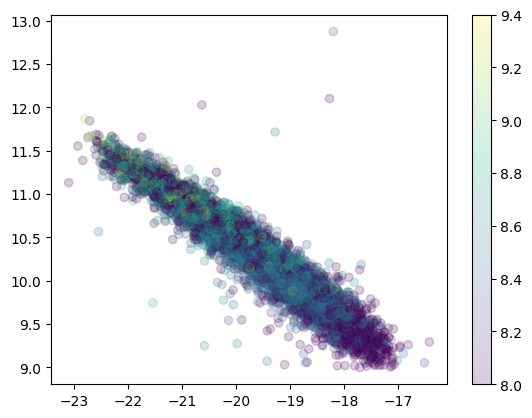

In [60]:
plt.scatter(spirals['rabsmag'], spirals['M90_disk'], c=spirals['Z'],vmin=8, vmax=9.4, alpha=0.2)
plt.colorbar()

(array([  40.,  317., 1419.,  991.,  406.,  140.,   22.]),
 array([8. , 8.2, 8.4, 8.6, 8.8, 9. , 9.2, 9.4]),
 <BarContainer object of 7 artists>)

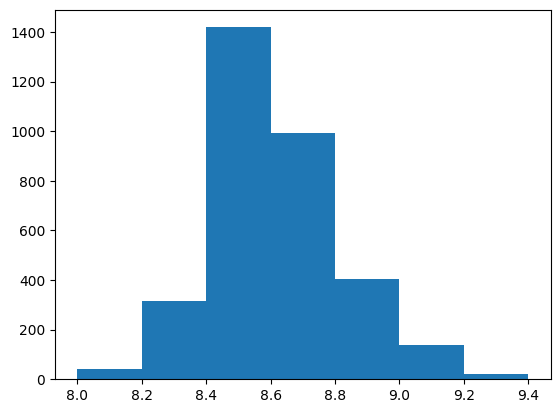

In [59]:
plt.hist(spirals['Z'][spirals['Z']>0], bins=(8,8.2,8.4,8.6,8.8,9,9.2,9.4))

### sphere and disk fits

Text(0, 0.5, '$\\log(M_*/M_\\odot)$')

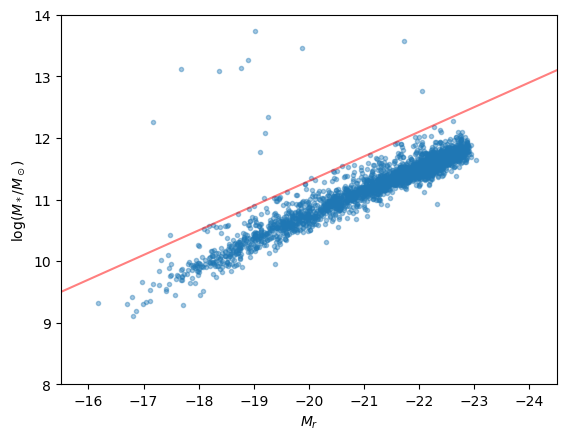

In [52]:
plt.scatter(ellipticals['rabsmag'],ellipticals['sphd_M_star'], marker='.', alpha=0.4)
plt.xlim(-15.5, -24.5)
# plt.plot([-15.5,-24.5],[8,11.5], color='r', alpha=0.5)
plt.plot([-15.5,-24.5],[9.5,13.1], color='r', alpha=0.5)
plt.ylim(8,14)
plt.xlabel(r'$M_r$')
plt.ylabel(r'$\log(M_*/M_\odot)$')
# plt.savefig(plot_dir + 'Mr_Mstarsphd_fifthfit_scatter.png')

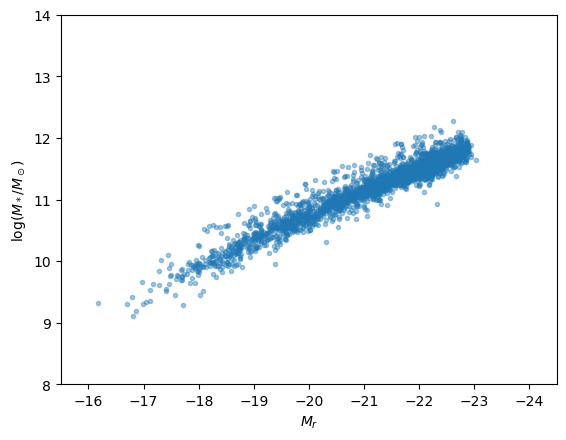

In [78]:
plt.scatter(good_fits['rabsmag'],good_fits['sphd_M_star'], marker='.', alpha=0.4)
plt.xlim(-15.5, -24.5)
# plt.plot([-15.5,-24.5],[8,11.5], color='r', alpha=0.5)
# plt.plot([-15.5,-24.5],[9.5,13.1], color='r', alpha=0.5)
plt.ylim(8,14)
plt.xlabel(r'$M_r$')
plt.ylabel(r'$\log(M_*/M_\odot)$')
plt.savefig(plot_dir + 'Mr_Mstarsphd_sixthfit_scatter.png')

In [73]:
bad = [ '8481-3704', '8995-12701', '9028-6104', '9181-12701', \
        '10500-9102', \
        '11744-6101', \
        '12490-12705',]

Text(0, 0.5, '$\\log(M_*/M_\\odot)$')

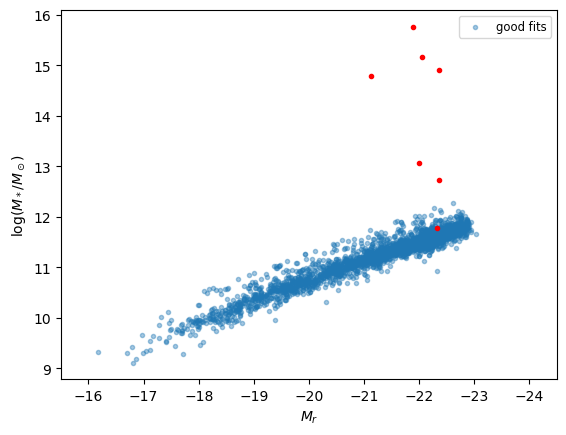

In [74]:
plt.scatter(good_fits['rabsmag'],good_fits['sphd_M_star'], marker='.', alpha=0.4, label='good fits')
# plt.scatter(bad_fits['rabsmag'],bad_fits['sphd_M_star'], marker='.', alpha=0.4, color='r', label='bad fits')
# plt.scatter(test_gal['rabsmag'], test_gal['sphd_M_star'], marker='x', color='k', label='test galaxy')

for i in bad:
    idx = ellipticals_dict[i]
    plt.scatter(ellipticals['rabsmag'][idx], ellipticals['sphd_M_star'][idx], marker='.', color='r')

plt.xlim(-15.5, -24.5)
# plt.plot([-15.5,-24.5],[8,11.5], color='r', alpha=0.5)
# plt.plot([-15.5,-24.5],[10,13.5], color='r', alpha=0.5)
plt.legend(fontsize='small')
# plt.ylim(8,18)
plt.xlabel(r'$M_r$')
plt.ylabel(r'$\log(M_*/M_\odot)$')

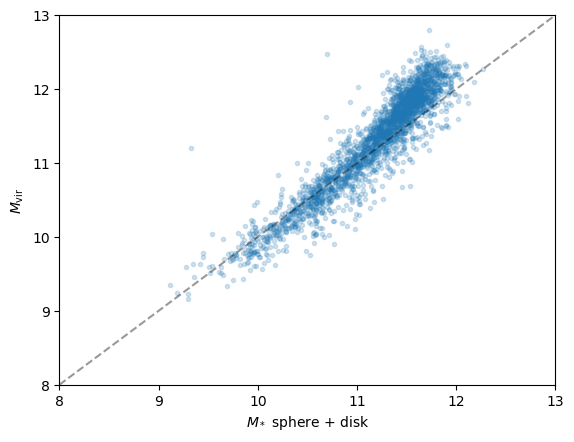

In [75]:
plt.scatter(good_fits['sphd_M_star'], good_fits['Mvir'], marker='.', alpha=0.2)
plt.xlim(8,13)
plt.plot([8,13],[8,13], linestyle='--', color='k', alpha=0.4)
plt.ylim(8,13)
plt.xlabel(r'$M_*$ sphere + disk')
plt.ylabel(r'$M_{\rm vir}$')
plt.savefig(plot_dir + 'Mstar_Mtot_sphdisk_good_ellipticals_scatter.png')

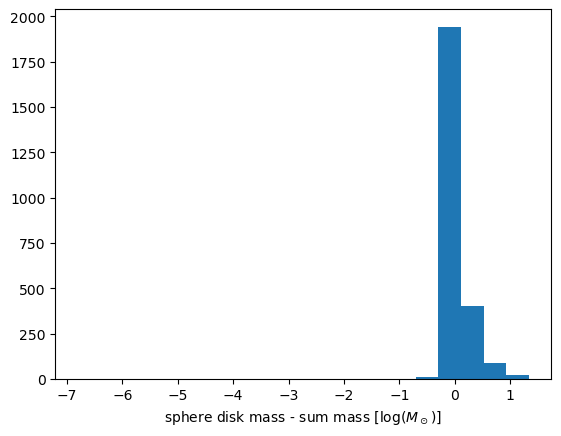

In [213]:
plt.hist(good_fits['sphd_M_star'] - good_fits['sum_M_star'], bins=20)
plt.xlabel(r'sphere disk mass - sum mass [$\log(M_\odot)]$')
plt.savefig(plot_dir + 'Mstar_sphdisk_sumMass_diff_hist.png')

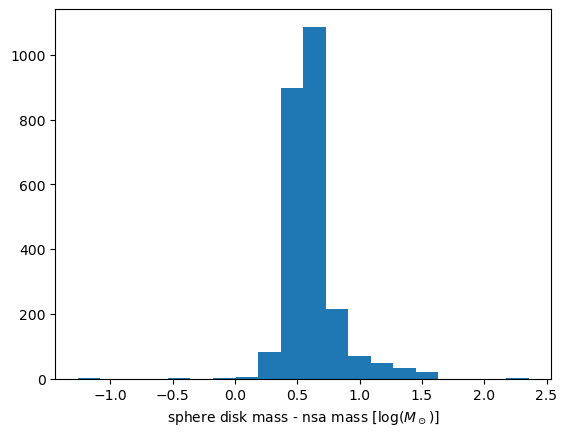

In [214]:
plt.hist(good_fits['sphd_M_star'] - good_fits['nsa_elpetro_log_mass'], bins=20)
plt.xlabel(r'sphere disk mass - nsa mass [$\log(M_\odot)$]')
plt.savefig(plot_dir + 'Mstar_sphdisk_nsaMass_diff_hist.png')

In [57]:
len(ellipticals)

2470

In [ ]:
bad=[  '8481-3704', '8995-12701', '9028-6104', '9181-12701', \
        '10500-9102', \
        '11744-6101', \
        '12490-12705',]

In [16]:
# removing galaxies
# '8725-12704' interacting
# '8329-9101' interacting
# '7991-9102' foreground obj
# '8087-6104' rotating
# '8146-12704' interacting
# '8257-6104' interacting

#'12679-9101' interacting
# '9185-12702' interacting
# idx = np.where(master_table['plateifu'] == '8257-6104')[0][0]
# master_table[idx]['Mvir'] = 0
# master_table[idx]['Mvir_err'] = 0


idx = np.where(master_table['plateifu'] == '12490-12705')[0][0]
master_table[idx]['sphd_M_star'] = 0
# master_table[idx]['Mvir_err'] = 0

In [17]:
master_table.write(master_table_fn, format='fits', overwrite=True)

In [245]:
np.where(master_table['plateifu'] == '8329-9101')[0][0]

6224

In [358]:
master_table[master_table['plateifu'] == '9078-9101']['Mvir']

<MaskedColumn name='Mvir' dtype='float64' length=0>